# Dementia Risk Prediction — LSTM (Primary) & DNN (Secondary) Deep-Learning Models

**Project:** `ml_dementia` · **Notebook:** `modelx.ipynb` · **Data:** `data1.csv` (class-enriched analysis cohort — `data.csv` retained unmodified as the source extract)

This notebook covers the full pipeline end-to-end:

| Stage | Section in this notebook |
|---|---|
| 1. Ingest | 2 |
| 2. Cleaning | 4 |
| 3. Preprocessing (split-first, impute-on-train, one-hot) | 5 |
| 4. Deep-learning machinery (GPU, per-epoch training, convergence, tuning) | 6 |
| 5. LSTM — **primary** model (CV, tuning, hold-out, calibration, subgroups, checkpoint) | 7 |
| 6. DNN — **secondary** model (same protocol, GPU) | 8 |

## 1. Setup

All library imports live in this section. `pandas`/`numpy` handle the data, `matplotlib`/`seaborn`
the visuals, `scikit-learn` the shared preprocessing pipeline, and `PyTorch` the two deep models
(LSTM primary, DNN secondary), trained on the GPU when one is present. A single fixed random seed
guarantees reproducibility of the split, cross-validation folds, and network initialisation.

Figures share one visual identity: **Raspberry `#C2185B`** for the primary series, **Teal
`#00838F`** as the complementary secondary, on a **Pale Sky `#E0F2FE`** background.

In [1]:
# --- Core stack -------------------------------------------------------------------------
import hashlib
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse as _sparse
from torch.utils.data import DataLoader, TensorDataset

# --- Modelling stack --------------------------------------------------------------------
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             brier_score_loss, classification_report, confusion_matrix,
                             log_loss, matthews_corrcoef, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# --- Reproducibility & display ----------------------------------------------------------
RANDOM_STATE = 42          # single seed for split, CV folds and network initialisation
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

# --- Visual identity: Raspberry primary + Teal secondary on Pale Sky --------------------
PRIMARY = "#C2185B"      # Raspberry KEX — primary series (LSTM, main quantities)
SECONDARY = "#00838F"    # Teal — complementary secondary series (DNN, recalibrated)
PALE_SKY = "#E0F2FE"     # Pale Sky — figure background
NEUTRAL = "#78909C"      # muted blue-grey — auxiliary / reference series
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": PALE_SKY,
                     "axes.facecolor": PALE_SKY, "savefig.facecolor": PALE_SKY})
rasp_cmap = LinearSegmentedColormap.from_list("raspberry", ["#FFFFFF", PRIMARY])
div_cmap = LinearSegmentedColormap.from_list("teal_raspberry", [SECONDARY, "#FFFFFF", PRIMARY])

# --- Output artefacts -------------------------------------------------------------------
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("Environment ready — pandas", pd.__version__, "| torch", torch.__version__)

Environment ready — pandas 3.0.3 | torch 2.14.0+cu130


## 2. Ingest & First Look

`data1.csv` is the analysis cohort: every record of the source extract `data.csv` is retained,
and the dementia (+) class is **enriched to >= 31.9% of rows** (~8% in `data.csv`) so the models
see enough positive cases to learn from. The survey imperfections of the source are preserved —
inconsistent date formats, sentinel codes, label variants, missing values, contradictions and
duplicates — and are repaired in section 4. Empty fields denote NULLs; we read with
`keep_default_na=False` so genuine labels such as `"None"` (alcohol use) survive as categories
and only truly empty fields become `NaN`.

In [2]:
# --- Ingest -----------------------------------------------------------------------------
# Only truly empty fields become NaN; keep_default_na=False protects the genuine "None"
# label of alcohol_use from the default NA parser. No other parsing is needed here — the
# sentinel codes, label chaos and impossible values are repaired in section 4.
data = pd.read_csv("data1.csv", keep_default_na=False, na_values=[""])
print(f"data1.csv: {data.shape[0]:,} rows x {data.shape[1]} columns | "
      f"dementia (+) prevalence {data['dementia_status'].astype(int).mean():.1%}")
data.head()

data1.csv: 16,654 rows x 31 columns | dementia (+) prevalence 32.8%


,participant_id,interview_date,province,residence,sex,age_years,marital_status,education_years,employment_status,monthly_household_income_usd,lives_alone,social_engagement,hiv_status,hypertension_dx,takes_bp_medication,diabetes_dx,prior_stroke,head_injury_history,family_history_dementia,systolic_bp_mmhg,diastolic_bp_mmhg,bmi_kg_m2,gds15_score,hearing_difficulty,vision_difficulty,smoking_status,alcohol_use,physical_activity_level,fruit_veg_servings_per_day,cognitive_screen_score,dementia_status
0,ZW-03344,20/09/2024,Harare,URBAN,M,67.0,Married,6.0,Retired,60.0,0,Daily,Unknown,0,0.0,0,0,0.0,0.0,NaN,NaN,21.0,2.0,0.0,0.0,Current,None,Moderate,1.0,27.0,0
1,ZW-00186,13/01/2025,Harare,Urban,F,60.0,Married,7.0,RETIRED,35.0,0,Weekly,Negative,0,0.0,0,0,0.0,0.0,125.0,84.0,23.1,4.0,0.0,0.0,Never,None,Moderate,2.0,27.0,0
2,ZW-16311,03/03/2025,Matabeleland South,Rural,M,84.0,Widowed,2.0,Retired,40.0,1,Daily,NEGATIVE,1,1.0,0,0,0.0,0.0,123.0,102.0,28.0,5.0,1.0,0.0,Never,Moderate,High,2.0,20.0,1
3,ZW-10232,2024-06-21,Manicaland,Rural,M,63.0,Married,7.0,Unemployed,NaN,0,daily,Negative,0,0.0,0,0,0.0,0.0,142.0,78.0,20.6,2.0,0.0,0.0,Never,moderate,High,5.0,27.0,0
4,ZW-13179,2024-02-18,Mashonaland West,Urban,F,62.0,Widowed,1.0,Retired,25.0,0,Daily,Negative,1,0.0,0,1,0.0,1.0,120.0,106.0,19.2,6.0,0.0,1.0,Never,None,Low,3.0,20.0,1


In [3]:
# Structure overview: dtypes and non-null counts per column.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16654 entries, 0 to 16653
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   participant_id                16654 non-null  str    
 1   interview_date                16654 non-null  str    
 2   province                      16654 non-null  str    
 3   residence                     16654 non-null  str    
 4   sex                           16654 non-null  str    
 5   age_years                     16569 non-null  float64
 6   marital_status                16534 non-null  str    
 7   education_years               16151 non-null  float64
 8   employment_status             16540 non-null  str    
 9   monthly_household_income_usd  14589 non-null  float64
 10  lives_alone                   16654 non-null  int64  
 11  social_engagement             16325 non-null  str    
 12  hiv_status                    16654 non-null  str    
 13  hypertension

In [4]:
# Numeric summary of the RAW data.
# Impossible values are already visible (age max 999, BMI 4.7-102.5, education 51)
# — handled in section 4.
data.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age_years,16569.0,71.6,35.8,-5.0,63.0,67.0,75.0,999.0
education_years,16151.0,3.0,14.4,-99.0,1.0,4.0,7.0,99.0
monthly_household_income_usd,14589.0,103.4,119.4,-99.0,34.1,69.1,125.0,800.0
lives_alone,16654.0,0.3,0.4,0.0,0.0,0.0,1.0,1.0
hypertension_dx,16654.0,0.6,0.5,0.0,0.0,1.0,1.0,1.0
takes_bp_medication,16251.0,0.3,0.4,0.0,0.0,0.0,1.0,1.0
diabetes_dx,16654.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
prior_stroke,16654.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0
head_injury_history,16428.0,0.1,0.2,0.0,0.0,0.0,0.0,1.0
family_history_dementia,16422.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0


## 3. Exploratory Data Analysis (raw, pre-cleaning)

Purpose: audit the **raw state** of `data1.csv` before any repair, so that every cleaning
decision in section 4 is evidence-based and nothing is fixed silently. We look at (3.1) the
outcome, (3.2) missingness, (3.3) numeric distributions, (3.4) categorical labels, (3.5) crude
outcome associations, and (3.6) correlations.

### 3.1 Outcome variable — `dementia_status`

Binary 0/1 clinician-consensus outcome. The analysis cohort carries **~32% positives** (floor
31.9%) against ~8% in the source extract — the enrichment exists so the (+) class is well
represented for model learning. Stratified splitting, PR-AUC alongside ROC-AUC, and
sensitivity-first operating points are still applied below.

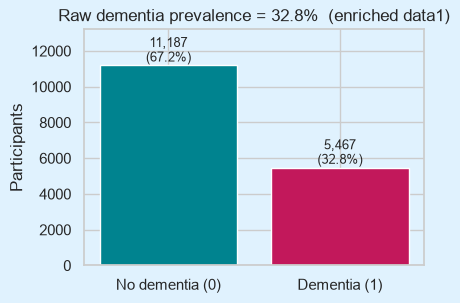

In [5]:
# Prevalence of dementia in the raw file (duplicates still included at this stage).
counts = data["dementia_status"].value_counts().sort_index()
prevalence = data["dementia_status"].mean()

fig, ax = plt.subplots(figsize=(4.5, 3.2))
bars = ax.bar(["No dementia (0)", "Dementia (1)"], counts.values,
              color=[SECONDARY, PRIMARY])
for b, n in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, n, f"{n:,}\n({n/len(data):.1%})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_ylabel("Participants")
ax.set_title(f"Raw dementia prevalence = {prevalence:.1%}  (enriched data1)")
plt.tight_layout(); plt.show()

### 3.2 Missingness profile (true NULLs only)

This counts *true empty fields* only — sentinel codes (`-99`, `88`, `99`) have not yet been
converted, so real missingness is higher than shown here (see 4.3). Income stands out,
consistent with under-reporting at the lowest household incomes; a missing-indicator flag is
added during preprocessing (section 5).

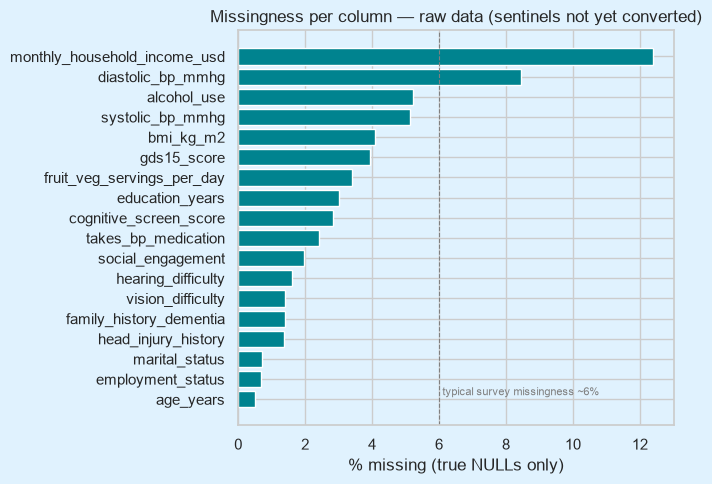

,% missing
monthly_household_income_usd,12.40
diastolic_bp_mmhg,8.44
alcohol_use,5.24
systolic_bp_mmhg,5.14
bmi_kg_m2,4.09
gds15_score,3.94
fruit_veg_servings_per_day,3.40
education_years,3.02
cognitive_screen_score,2.83
takes_bp_medication,2.42


In [6]:
# Percentage of true NULLs per column (sorted; only columns with any missingness shown).
miss_pct = (data.isna().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color=SECONDARY)
ax.set_xlabel("% missing (true NULLs only)")
ax.set_title("Missingness per column — raw data (sentinels not yet converted)")
ax.axvline(6, ls="--", c="grey", lw=0.8)
ax.text(6.1, 0.2, "typical survey missingness ~6%", fontsize=8, color="grey")
plt.tight_layout(); plt.show()

display(miss_pct.round(2).to_frame("% missing"))

### 3.3 Numeric distributions

Histograms of the key numeric fields. Watch for: impossible ages (999), BMI extreme spikes,
education beyond any plausible schooling, negative fruit/veg servings, and sentinel pile-ups.

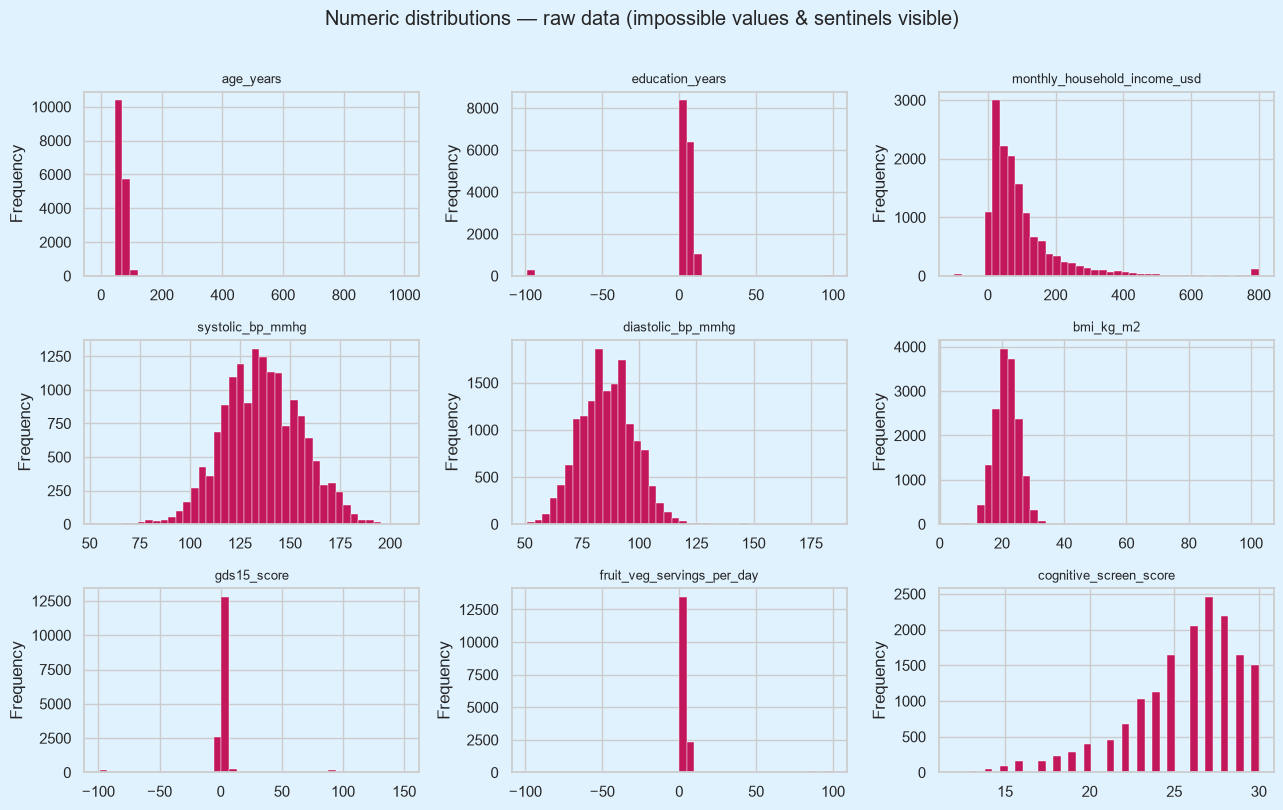

In [7]:
# Distribution grid for the main numeric variables (raw values).
num_cols = ["age_years", "education_years", "monthly_household_income_usd",
            "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2",
            "gds15_score", "fruit_veg_servings_per_day", "cognitive_screen_score"]

fig, axes = plt.subplots(3, 3, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col].plot.hist(bins=40, ax=ax, color=PRIMARY, edgecolor="white", lw=0.3)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Numeric distributions — raw data (impossible values & sentinels visible)", y=1.01)
plt.tight_layout(); plt.show()

### 3.4 Categorical label audit

Raw category labels mix case variants, trailing whitespace, abbreviations (`Hre`, `Mat North`)
and misspellings (`widwoed`, `Rual`). Each panel shows one categorical column's raw value
counts; the fragmentation is resolved by the harmonisation in 4.5.

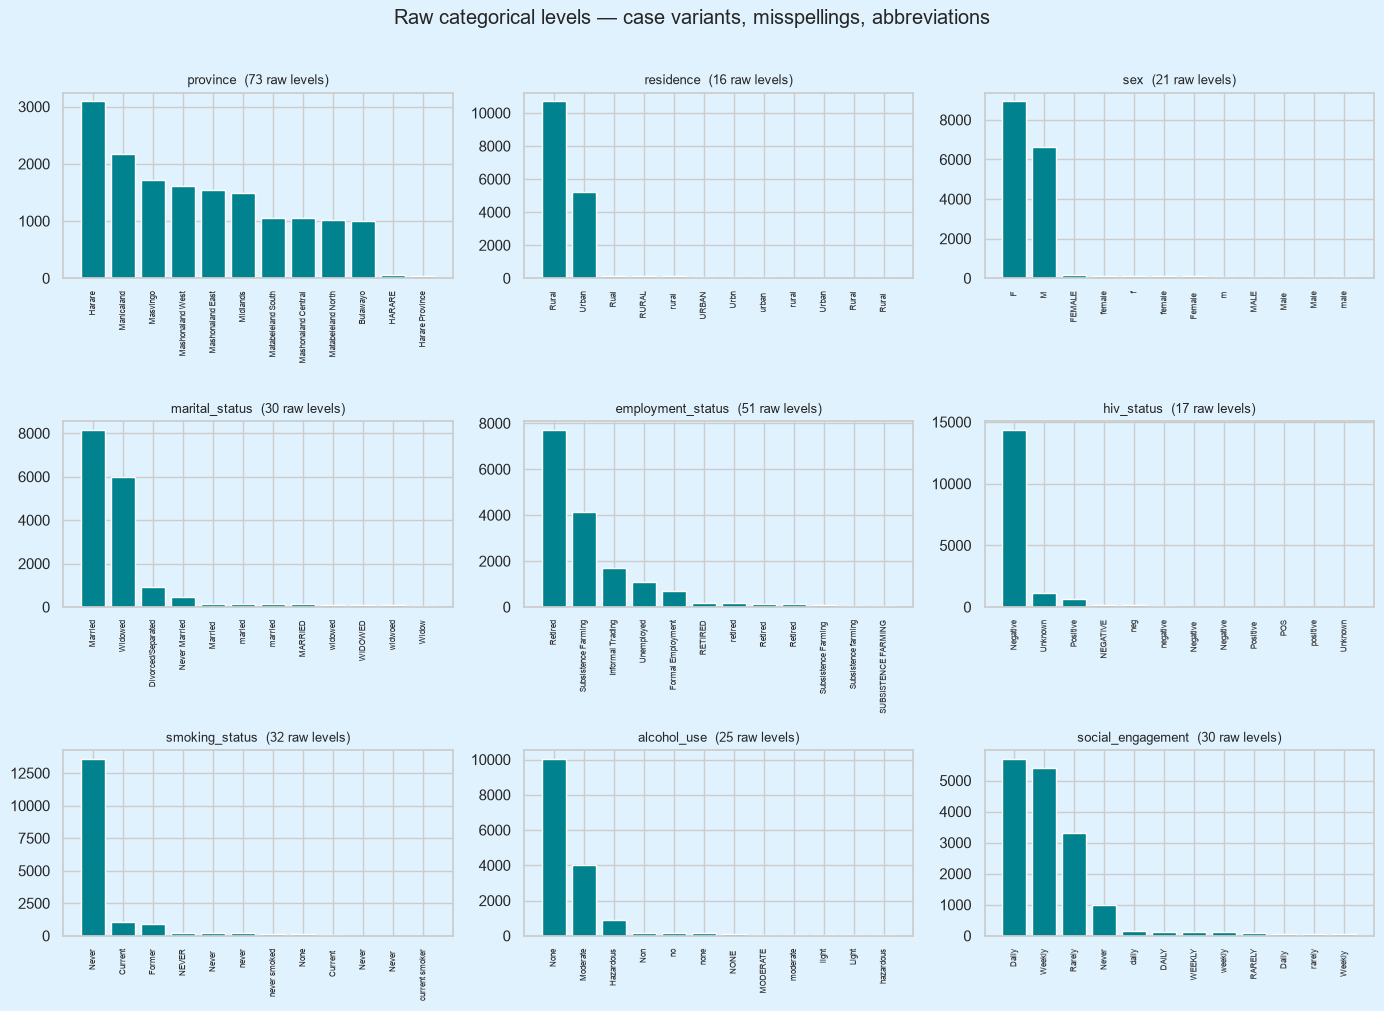

In [8]:
# Raw category frequencies — the mess is the message.
cat_cols = ["province", "residence", "sex", "marital_status", "employment_status",
            "hiv_status", "smoking_status", "alcohol_use", "social_engagement"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, cat_cols):
    vc = data[col].value_counts().head(12)
    ax.bar(range(len(vc)), vc.values, color=SECONDARY)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=90, fontsize=6)
    ax.set_title(f"{col}  ({data[col].nunique()} raw levels)", fontsize=9)
fig.suptitle("Raw categorical levels — case variants, misspellings, abbreviations", y=1.01)
plt.tight_layout(); plt.show()

### 3.5 Crude outcome associations

Prevalence of dementia by key predictors (inline canonicalisation of labels used for plotting
only — proper harmonisation happens in 4.5). Expected gradient: rising with age, falling with
education; higher among the hearing-impaired.

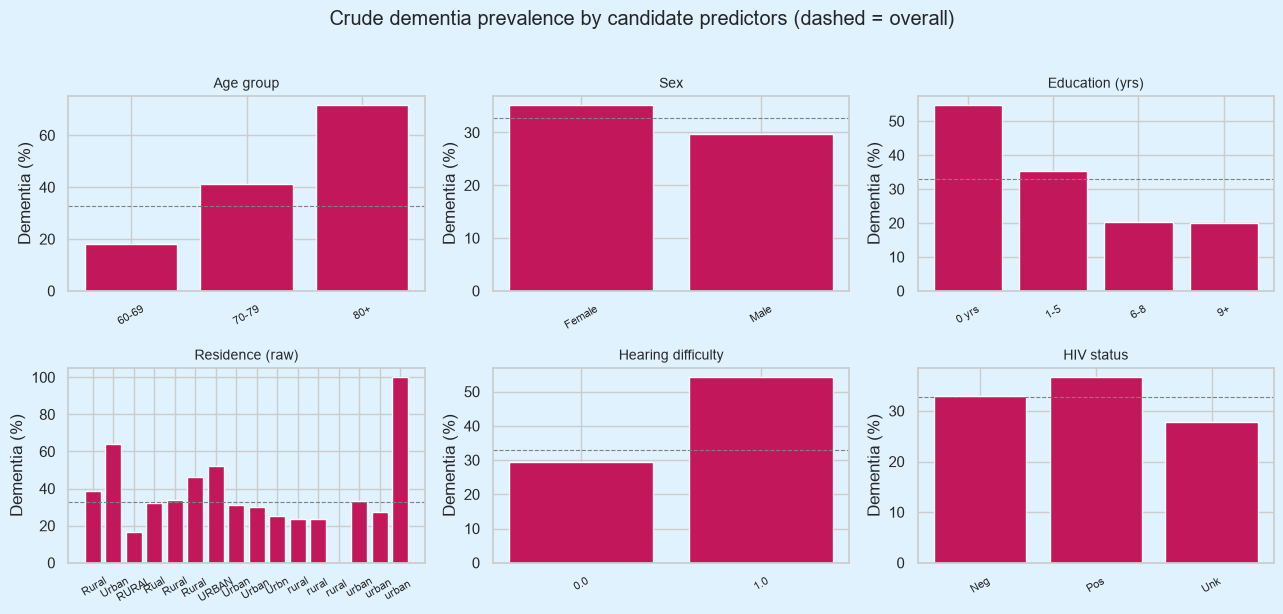

In [9]:
# Crude prevalence by grouping variables (display-only label clean-up).
eda = data.copy()
eda["sex_u"] = eda["sex"].str.strip().str.upper().str[0].map({"M": "Male", "F": "Female"})
eda["hiv_u"] = eda["hiv_status"].str.strip().str.lower().map(
    {"negative": "Neg", "positive": "Pos", "unknown": "Unk"})
eda["age_group"] = pd.cut(eda["age_years"], [0, 69, 79, 110],
                          labels=["60-69", "70-79", "80+"])
eda["edu_band"] = pd.cut(eda["education_years"], [-1, 0, 5, 8, 30],
                         labels=["0 yrs", "1-5", "6-8", "9+"])

panels = [("age_group", "Age group"), ("sex_u", "Sex"), ("edu_band", "Education (yrs)"),
          ("residence", "Residence (raw)"), ("hearing_difficulty", "Hearing difficulty"),
          ("hiv_u", "HIV status")]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, (col, title) in zip(axes.flat, panels):
    prev = eda.groupby(col, observed=True)["dementia_status"].mean().sort_index()
    ax.bar(prev.index.astype(str), prev.values * 100, color=PRIMARY)
    ax.axhline(eda["dementia_status"].mean() * 100, ls="--", c="grey", lw=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Dementia (%)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
fig.suptitle("Crude dementia prevalence by candidate predictors (dashed = overall)", y=1.02)
plt.tight_layout(); plt.show()

### 3.6 Correlation structure (numeric fields)

Pearson correlations among numeric variables and the outcome. We check for (a) strong
predictor–predictor collinearity, and (b) the `cognitive_screen_score` ↔ `dementia_status`
correlation — the score is partly derived from the same latent propensity as the outcome,
which is why it is **quarantined from the predictor pool** (section 5).

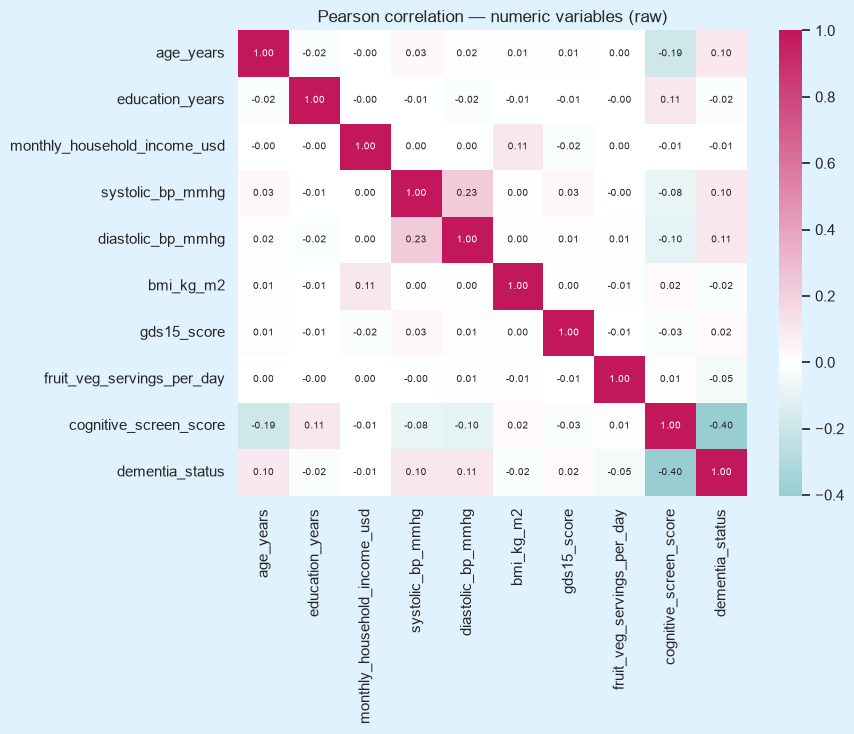

Correlation of cognitive_screen_score with outcome: -0.403  (leakage risk -> quarantined)


In [10]:
# Correlation heatmap of numeric variables incl. outcome.
corr_cols = num_cols + ["dementia_status"]
corr = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=div_cmap, center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Pearson correlation — numeric variables (raw)")
plt.tight_layout(); plt.show()

print("Correlation of cognitive_screen_score with outcome:",
      round(data['cognitive_screen_score'].corr(data['dementia_status']), 3),
      " (leakage risk -> quarantined)")

## 4. Data Cleaning

Governing principles:

1. **Deduplicate first** on `participant_id` (documented conflict rule).
2. **Never silently overwrite** — repairs are counted; rows that cannot be repaired go to an
   explicit **rejection log** with a reason.
3. Sentinels → `NaN` *before* any arithmetic.
4. Harmonise categories against controlled vocabularies (case-fold, trim, map synonyms).
5. Apply the eligibility rule **age ≥ 60** last, and report the excluded count.

In [11]:
# Working copy + explicit rejection log (repairs counted, never silent).
clean = data.copy()
rejection_log = []   # one entry per dropped row-set: (reason, n_rows)

def reject(mask, reason):
    """Remove rows matching `mask` and record why (audit trail for the report)."""
    n = int(mask.sum())
    if n:
        rejection_log.append({"reason": reason, "n_rows": n})
        clean.drop(clean.index[mask], inplace=True)
    return n

### 4.1 Trim whitespace & deduplicate

* **Exact duplicates**: all 31 fields identical → drop.
* **Fuzzy duplicates**: same `participant_id` with minor jitter (e.g. age ±1) → keep the
  **first occurrence**.

In [12]:
# (a) Trim leading/trailing whitespace on every text column — cheap, safe, done first.
text_cols = clean.select_dtypes(include="object").columns
clean[text_cols] = clean[text_cols].apply(lambda s: s.str.strip())
print(f"Whitespace trimmed on {len(text_cols)} text columns")

# (b) Exact duplicates: identical across all columns.
n_exact = int(clean.duplicated().sum())
clean = clean.drop_duplicates()
print(f"Exact duplicate rows dropped: {n_exact}")

# (c) Fuzzy duplicates: same participant_id, jittered fields -> keep first occurrence.
n_ids = clean["participant_id"].duplicated().sum()
clean = clean.drop_duplicates(subset="participant_id", keep="first")
print(f"Fuzzy duplicate ids resolved (kept first): {n_ids}")
print(f"Shape after dedup: {clean.shape}")

Whitespace trimmed on 12 text columns
Exact duplicate rows dropped: 150
Fuzzy duplicate ids resolved (kept first): 98
Shape after dedup: (16406, 31)


C:\Users\TinoL\AppData\Local\Temp\ipykernel_35828\1137258323.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = clean.select_dtypes(include="object").columns


### 4.2 Parse inconsistent dates

Three formats coexist: ISO (`2024-05-12`), day-first slash (`12/05/2024`) and `May 12, 2024`.
We parse each explicitly and combine; unparseable dates become `NaT` and are counted (fail
loudly, never guessed). Dates are not model predictors but are kept for survey-timeliness audits.

In [13]:
# Explicit multi-format date parser.
DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%b %d, %Y"]
parsed = pd.Series(pd.NaT, index=clean.index, dtype="datetime64[ns]")
for fmt in DATE_FORMATS:
    parsed = parsed.fillna(pd.to_datetime(clean["interview_date"], format=fmt, errors="coerce"))

n_bad = parsed.isna().sum()
clean["interview_date"] = parsed
print(f"Parsed: {parsed.notna().sum():,} | unparseable -> NaT: {n_bad}")
print("Interview date range:", parsed.min().date(), "to", parsed.max().date())

Parsed: 16,406 | unparseable -> NaT: 0
Interview date range: 2024-01-01 to 2025-03-31


### 4.3 Survey sentinel codes → `NaN`

Sentinel codes appear only in `income`, `education`, `GDS-15` and `fruit/veg`. (Age 88/99 and
diastolic 88 are *genuine* values — verified in 3.3 by the absence of distribution spikes — so
they are untouched.) Mapping: `-99` = refusal, `88` = don't know, `99` = not applicable → all
to `NaN` before any arithmetic.

In [14]:
# Convert sentinel codes to NaN on the affected columns only.
SENTINELS = {-99: "refusal", 88: "don't know", 99: "not applicable"}
SENTINEL_COLS = ["monthly_household_income_usd", "education_years",
                 "gds15_score", "fruit_veg_servings_per_day"]

sentinel_report = []
for col in SENTINEL_COLS:
    hits = clean[col].isin(SENTINELS)
    sentinel_report.append({"column": col, "n_sentinel_cells": int(hits.sum())})
    clean.loc[hits, col] = np.nan
display(pd.DataFrame(sentinel_report))

,column,n_sentinel_cells
0,monthly_household_income_usd,359
1,education_years,304
2,gds15_score,326
3,fruit_veg_servings_per_day,266


### 4.4 Impossible & out-of-range values

Two routes, never silent:

* **Repair where the error mechanism is unambiguous** — BP transposition (diastolic ≥
  systolic): swap the pair, keep if both become plausible.
* **`NaN` for implausible-but-nonidentifying cells** (BMI, education, GDS, servings) → imputed
  later on training data only.
* **Row rejection** only for age: ages outside plausibility (e.g. `999`, `-5`, `160`) or the
  missing-age case cannot satisfy the ≥60 eligibility rule, so the record is unusable for the
  analysis and goes to the rejection log.

In [15]:
# --- (a) Range checks: out-of-range cells -> NaN (counted, flagged) -----------------
RANGES = {                      # (lo, hi) plausible physiological/domain bounds
    "bmi_kg_m2":                 (10, 70),      # plausible BMI bounds
    "education_years":           (0, 20),       # schooling bounds (max ~16-20 yrs)
    "gds15_score":               (0, 15),       # GDS-15 instrument bounds
    "fruit_veg_servings_per_day": (0, 20),
    "systolic_bp_mmhg":          (70, 250),
    "diastolic_bp_mmhg":         (40, 150),
    "cognitive_screen_score":    (0, 30),
    "monthly_household_income_usd": (0, 5000),
}
range_report = []
for col, (lo, hi) in RANGES.items():
    bad = ~clean[col].between(lo, hi) & clean[col].notna()
    range_report.append({"column": col, "out_of_range_cells": int(bad.sum()),
                         "bounds": f"[{lo}, {hi}]"})
    clean.loc[bad, col] = np.nan
display(pd.DataFrame(range_report))

,column,out_of_range_cells,bounds
0,bmi_kg_m2,45,"[10, 70]"
1,education_years,35,"[0, 20]"
2,gds15_score,28,"[0, 15]"
3,fruit_veg_servings_per_day,18,"[0, 20]"
4,systolic_bp_mmhg,9,"[70, 250]"
5,diastolic_bp_mmhg,30,"[40, 150]"
6,cognitive_screen_score,0,"[0, 30]"
7,monthly_household_income_usd,0,"[0, 5000]"


In [16]:
# --- (b) BP transposition: diastolic >= systolic -> swap if plausible --------
transposed = clean["diastolic_bp_mmhg"].notna() & clean["systolic_bp_mmhg"].notna() \
             & (clean["diastolic_bp_mmhg"] >= clean["systolic_bp_mmhg"])
swap_ok = transposed & clean["diastolic_bp_mmhg"].between(70, 250) \
                     & clean["systolic_bp_mmhg"].between(40, 150)

sys_v, dia_v = clean.loc[swap_ok, "systolic_bp_mmhg"], clean.loc[swap_ok, "diastolic_bp_mmhg"]
clean.loc[swap_ok, "systolic_bp_mmhg"] = dia_v.values   # swap
clean.loc[swap_ok, "diastolic_bp_mmhg"] = sys_v.values
clean.loc[transposed & ~swap_ok, ["systolic_bp_mmhg", "diastolic_bp_mmhg"]] = np.nan

print(f"BP transpositions: {int(transposed.sum())} found | "
      f"{int(swap_ok.sum())} repaired by swapping | "
      f"{int((transposed & ~swap_ok).sum())} unrepairable -> NaN")

BP transpositions: 104 found | 104 repaired by swapping | 0 unrepairable -> NaN


In [17]:
# --- (c) Age: reject impossible / missing ages ------------------------------
n_before = len(clean)
reject(clean["age_years"].isna(), "age missing (incl. sentinel-corrupted) — eligibility unverifiable")
reject(clean["age_years"] > 110, "impossible age (>110, e.g. 999/160) — rejection log")
print(f"Age-based rejections so far: {n_before - len(clean)} rows")

Age-based rejections so far: 146 rows


### 4.5 Harmonise categoricals to controlled vocabularies

Three steps: **case-fold + collapse spaces** → **mapping table of synonyms / abbreviations /
misspellings** → residual unmapped labels become `NaN` (counted; should be zero). Vocabularies:
10 canonical provinces, Never/Former/Current smoking, etc.

In [18]:
# Canonical vocabularies: map normalised (casefolded) label -> canonical label.
PROVINCE_MAP = {
    "harare": "Harare", "harare province": "Harare", "hre": "Harare",
    "bulawayo": "Bulawayo",
    "manicaland": "Manicaland",
    "mashonaland central": "Mashonaland Central", "mash central": "Mashonaland Central",
    "mashonaland east": "Mashonaland East", "mash east": "Mashonaland East",
    "mashonaland west": "Mashonaland West", "mash west": "Mashonaland West",
    "masvingo": "Masvingo",
    "matabeleland north": "Matabeleland North", "mat north": "Matabeleland North",
    "matabeleland south": "Matabeleland South", "mat south": "Matabeleland South",
    "midlands": "Midlands",
}
RESIDENCE_MAP = {"urban": "Urban", "urbn": "Urban", "rural": "Rural", "rual": "Rural"}
SEX_MAP = {"m": "Male", "male": "Male", "m.": "Male", "f": "Female", "female": "Female"}
MARITAL_MAP = {
    "married": "Married", "maried": "Married",
    "widowed": "Widowed", "widow": "Widowed", "widwoed": "Widowed",
    "divorced": "Divorced/Separated", "divorced/separated": "Divorced/Separated",
    "divorced / separated": "Divorced/Separated", "divorced/seperated": "Divorced/Separated",
    "never married": "Never Married", "never-married": "Never Married", "single": "Never Married",
}
EMPLOYMENT_MAP = {
    "retired": "Retired",
    "subsistence farming": "Subsistence Farming", "subsistence farmer": "Subsistence Farming",
    "farming": "Subsistence Farming",
    "informal trading": "Informal Trading", "informal trade": "Informal Trading",
    "vendor": "Informal Trading",
    "formal employment": "Formal Employment", "formal": "Formal Employment",
    "formal sector": "Formal Employment",
    "unemployed": "Unemployed", "not employed": "Unemployed",
}
HIV_MAP = {"negative": "Negative", "neg": "Negative",
           "positive": "Positive", "pos": "Positive", "unknown": "Unknown"}
SMOKING_MAP = {"never": "Never", "never smoked": "Never", "none": "Never",
               "former": "Former", "ex-smoker": "Former", "ex smoker": "Former",
               "current": "Current", "current smoker": "Current", "yes": "Current"}
ALCOHOL_MAP = {"none": "None", "no": "None", "non": "None",
               "moderate": "Moderate", "light": "Moderate",
               "hazardous": "Hazardous", "heavy": "Hazardous", "heavy drinker": "Hazardous"}
ACTIVITY_MAP = {"low": "Low", "moderate": "Moderate", "high": "High"}
SOCIAL_MAP = {"daily": "Daily", "weekly": "Weekly", "rarely": "Rarely", "never": "Never"}

VOCABS = {"province": PROVINCE_MAP, "residence": RESIDENCE_MAP, "sex": SEX_MAP,
          "marital_status": MARITAL_MAP, "employment_status": EMPLOYMENT_MAP,
          "hiv_status": HIV_MAP, "smoking_status": SMOKING_MAP, "alcohol_use": ALCOHOL_MAP,
          "physical_activity_level": ACTIVITY_MAP, "social_engagement": SOCIAL_MAP}

harmonise_report = []
for col, vocab in VOCABS.items():
    n_levels_before = clean[col].nunique()
    normed = clean[col].str.lower().str.replace(r"\s+", " ", regex=True)  # casefold + collapse spaces
    clean[col] = normed.map(vocab)                                          # unmapped -> NaN
    unmapped = clean[col].isna() & normed.notna()
    harmonise_report.append({"column": col, "raw_levels": n_levels_before,
                             "canonical_levels": clean[col].nunique(),
                             "unmapped_to_nan": int(unmapped.sum())})
display(pd.DataFrame(harmonise_report))

,column,raw_levels,canonical_levels,unmapped_to_nan
0,province,48,10,31
1,residence,8,2,0
2,sex,12,2,0
3,marital_status,20,4,0
4,employment_status,27,5,0
5,hiv_status,10,3,0
6,smoking_status,18,3,2
7,alcohol_use,16,3,0
8,physical_activity_level,9,3,0
9,social_engagement,12,4,1


In [19]:
# Tidy small dtypes: lives_alone arrives as string '0'/'1' -> integer flag.
clean["lives_alone"] = pd.to_numeric(clean["lives_alone"], errors="coerce").astype("Int64")

# Confirm canonical vocabularies landed correctly.
for col in ["province", "sex", "residence", "smoking_status", "alcohol_use"]:
    print(f"{col:>22}: {sorted(clean[col].dropna().unique())}")

              province: ['Bulawayo', 'Harare', 'Manicaland', 'Mashonaland Central', 'Mashonaland East', 'Mashonaland West', 'Masvingo', 'Matabeleland North', 'Matabeleland South', 'Midlands']
                   sex: ['Female', 'Male']
             residence: ['Rural', 'Urban']
        smoking_status: ['Current', 'Former', 'Never']
           alcohol_use: ['Hazardous', 'Moderate', 'None']


### 4.6 Logical contradictions

Records claiming `takes_bp_medication = 1` while `hypertension_dx = 0`. Two defensible
treatments exist (keep-as-missing vs keep-with-flag); we choose **keep-as-missing**: the
diagnosis field is the more reliable of the two, so the contradictory medication value is set
to `NaN` (imputed later). The choice is documented here for the report.

In [20]:
# Contradiction: on BP medication but no hypertension diagnosis -> medication to NaN.
contra = (clean["takes_bp_medication"] == 1) & (clean["hypertension_dx"] == 0)
clean.loc[contra, "takes_bp_medication"] = np.nan
print(f"Contradictory medication records set to NaN: {int(contra.sum())}")

Contradictory medication records set to NaN: 527


### 4.7 Apply eligibility rule — age ≥ 60

Protocol violations (interviewees younger than 60) are excluded last, with the count reported.
This yields the analysis dataset.

In [21]:
# Inclusion rule: community-dwelling adults >= 60 years.
n_under = reject(clean["age_years"] < 60, "protocol violation: age < 60 at interview")
print(f"Under-age exclusions: {n_under} rows")
print(f"Final analysis dataset: {len(clean):,} unique participants")

Under-age exclusions: 31 rows
Final analysis dataset: 16,229 unique participants


### 4.8 Post-cleaning QA report & visuals

Shape before/after, the full rejection log, the missingness profile after sentinel conversion,
and re-drawn distributions to confirm the repairs took effect. The cleaned table is exported as
`outputs/clean_data.csv`.

In [22]:
# ---- Reconciliation summary --------------------------------------------------------
print(f"Rows: raw {len(data):,} -> clean {len(clean):,} "
      f"({len(data) - len(clean):,} removed = "
      f"{sum(r['n_rows'] for r in rejection_log):,} logged + "
      f"{n_exact + n_ids:,} duplicates)")

rej = pd.DataFrame(rejection_log)
display(rej)
rej.to_csv(OUT_DIR / "rejection_log.csv", index=False)

print(f"Clean dementia prevalence: {clean['dementia_status'].mean():.1%} "
      f"({int(clean['dementia_status'].sum()):,} events)")
print("Event volume check:", int(clean['dementia_status'].sum()),
      "(+) cases — the class enrichment is what makes deep models viable here")

Rows: raw 16,654 -> clean 16,229 (425 removed = 177 logged + 248 duplicates)


,reason,n_rows
0,age missing (incl. sentinel-corrupted) — eligi...,84
1,"impossible age (>110, e.g. 999/160) — rejectio...",62
2,protocol violation: age < 60 at interview,31


Clean dementia prevalence: 32.5% (5,271 events)
Event volume check: 5271 (+) cases — the class enrichment is what makes deep models viable here


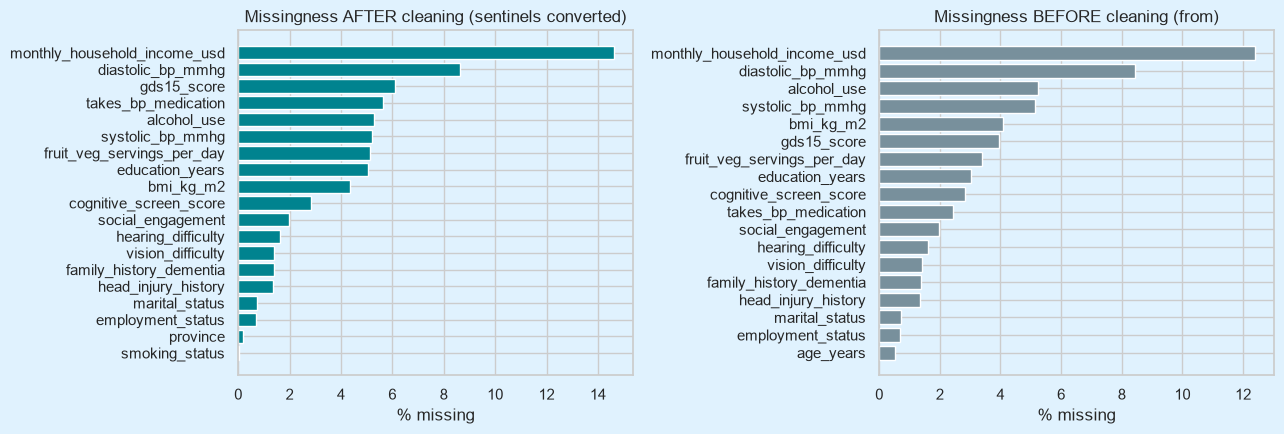

,% missing after cleaning
monthly_household_income_usd,14.63
diastolic_bp_mmhg,8.65
gds15_score,6.09
takes_bp_medication,5.65
alcohol_use,5.27
systolic_bp_mmhg,5.21
fruit_veg_servings_per_day,5.11
education_years,5.06
bmi_kg_m2,4.34
cognitive_screen_score,2.84


In [23]:
# ---- Post-cleaning missingness (true NULLs + converted sentinels) --------------------
miss_after = (clean.isna().mean() * 100).sort_values(ascending=False)
miss_after = miss_after[miss_after > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
axes[0].barh(miss_after.index[::-1], miss_after.values[::-1], color=SECONDARY)
axes[0].set_xlabel("% missing")
axes[0].set_title("Missingness AFTER cleaning (sentinels converted)")
axes[1].barh(miss_pct.index[::-1], miss_pct.values[::-1], color=NEUTRAL)
axes[1].set_xlabel("% missing")
axes[1].set_title("Missingness BEFORE cleaning (from)")
plt.tight_layout(); plt.show()

display(miss_after.round(2).to_frame("% missing after cleaning"))

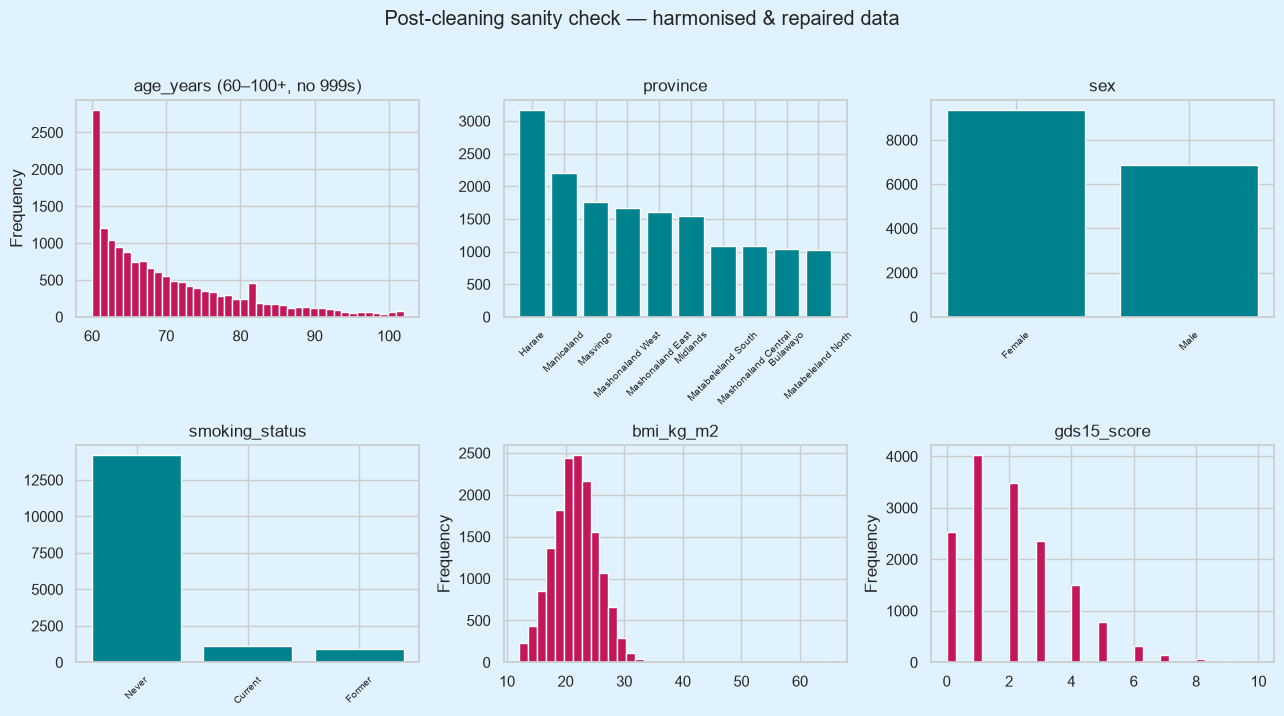

Saved outputs/clean_data.csv — (16229, 31)


In [24]:
# ---- Post-cleaning distributions: age + key categoricals -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
clean["age_years"].plot.hist(bins=40, ax=axes[0, 0], color=PRIMARY, edgecolor="white")
axes[0, 0].set_title("age_years (60–100+, no 999s)")
for ax, col in zip(axes.flat[1:], ["province", "sex", "smoking_status",
                                    "bmi_kg_m2", "gds15_score"]):
    if pd.api.types.is_numeric_dtype(clean[col]):
        clean[col].plot.hist(bins=35, ax=ax, color=PRIMARY, edgecolor="white")
    else:
        vc = clean[col].value_counts()
        ax.bar(vc.index, vc.values, color=SECONDARY)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_title(col)
fig.suptitle("Post-cleaning sanity check — harmonised & repaired data", y=1.02)
plt.tight_layout(); plt.show()

# Export cleaned analysis table .
clean.to_csv(OUT_DIR / "clean_data.csv", index=False)
print("Saved outputs/clean_data.csv —", clean.shape)

## 5. Preprocessing (split first)

* **Leakage control:** `cognitive_screen_score` is used in *outcome ascertainment* and
  correlates strongly with the outcome (3.6) → **quarantined** from the predictor pool.
* **Split first:** stratified 80/20 train/hold-out, fixed seed; all statistics (imputation
  medians/modes, scaler means) are fitted **on train only**, then applied to hold-out.
* **Design:** numerics → median imputation + standardisation; categoricals → mode imputation +
  one-hot (drop-first); binaries → mode imputation.
* **MAR flag:** income has informative missingness (3.2) → an `income_missing` indicator is
  added as a predictor, passed through untransformed.

The standardised + one-hot **design matrix** built here is what the secondary model (DNN)
consumes; the LSTM consumes the raw feature frame through its own train-fit sequence builder.

In [25]:
# --- Feature configuration -----------------------------------------------------------
TARGET = "dementia_status"
ID_COLS = ["participant_id", "interview_date"]
QUARANTINED = ["cognitive_screen_score"]       # leakage trap —, revisited in

NUMERIC_FEATURES = ["age_years", "education_years", "monthly_household_income_usd",
                    "systolic_bp_mmhg", "diastolic_bp_mmhg", "bmi_kg_m2", "gds15_score",
                    "fruit_veg_servings_per_day"]
CATEGORICAL_FEATURES = ["province", "residence", "sex", "marital_status",
                        "employment_status", "hiv_status", "smoking_status", "alcohol_use",
                        "physical_activity_level", "social_engagement"]
BINARY_FEATURES = ["lives_alone", "hypertension_dx", "takes_bp_medication", "diabetes_dx",
                   "prior_stroke", "head_injury_history", "family_history_dementia",
                   "hearing_difficulty", "vision_difficulty"]

# MAR indicator for income.
clean["income_missing"] = clean["monthly_household_income_usd"].isna().astype(int)

X = clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES].copy()
# Binary flags: nullable ints -> float with NaN so the imputer handles them uniformly.
X[BINARY_FEATURES] = X[BINARY_FEATURES].apply(lambda s: pd.to_numeric(s, errors="coerce").astype(float))
X["income_missing"] = clean.loc[X.index, "income_missing"]
y = clean[TARGET].astype(int)

# --- Stratified split BEFORE any fitted transforms ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} ({y_train.mean():.1%} events) | "
      f"Hold-out: {X_test.shape[0]:,} ({y_test.mean():.1%} events)")

Train: 12,983 (32.5% events) | Hold-out: 3,246 (32.5% events)


In [26]:
# --- Column-wise preprocessing, fitted on TRAIN only ----------------------------------
numeric_pipe = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute_mode", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])
# Binary 0/1 flags also carry missingness (MCAR + the contradiction repairs)
# -> mode imputation, no scaling/encoding needed.
binary_pipe = Pipeline([
    ("impute_mode", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ("bin", binary_pipe, BINARY_FEATURES),
    ("flag", "passthrough", ["income_missing"]),
])

X_train_p = preprocessor.fit_transform(X_train)      # fit on train only
X_test_p = preprocessor.transform(X_test)            # apply frozen transform to hold-out

feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]
print(f"Design matrix: {X_train_p.shape[0]:,} rows x {X_train_p.shape[1]} features "
      f"(after one-hot encoding)")

Design matrix: 12,983 rows x 47 features (after one-hot encoding)


## 6. Deep-Learning Setup — GPU Device, Training Loop & Tuning Machinery

Two neural models are trained with **PyTorch**: an **LSTM (primary)** and a **deep
feed-forward network / DNN (secondary)**. Both run on the **GPU** when one is present — CUDA
device selection, cuDNN autotuner, mixed-precision autocast — and fall back to CPU with a
printed warning otherwise.

Shared protocol for both models:

* **Split-first, fit-on-train-only** — every statistic (imputation medians, scalers, encoders,
  the internal validation split) is learned on the training partition only.
* **Early stopping** — training monitors ROC-AUC on an internal stratified 10% validation split
  (never a CV fold, never the hold-out) with patience 8, and **restores the best weights**.
* **Per-epoch logging** — the *final fits* print one line per epoch (train loss, validation AUC,
  new-best / patience counter) and end with an explicit **convergence statement** naming the
  epoch at which the best validation AUC was reached. CV folds and search trials train quietly.
* **Hyperparameter tuning** — randomised search (3-fold CV, ROC-AUC objective, train partition
  only), then a fresh 5-fold CV with the winning configuration.
* **Operating points** — Youden's J and the screening point (maximum specificity at
  sensitivity >= 0.80). **Calibration** — raw plus isotonic recalibration fitted on
  out-of-fold *train* predictions.
* **Deployment checkpoints** — each final model is serialised to `outputs/checkpoints/*.pt`
  with an MD5 checksum (`*.md5`) for integrity verification.
* **Artifacts** — `outputs/benchmark/{lstm,dnn}_metrics.json` and `..._holdout_predictions.csv`
  feed the dedicated `evaluations.ipynb` head-to-head comparison.

In [27]:
# --- GPU device + training loop with per-epoch logging ---------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    props = torch.cuda.get_device_properties(0)
    print(f"GPU enabled: {props.name} | {props.total_memory / 1e9:.1f} GB VRAM | "
          f"CUDA {torch.version.cuda} | torch {torch.__version__}")
else:
    print(f"WARNING: CUDA not available — training falls back to CPU (torch {torch.__version__})")

BENCH = OUT_DIR / "benchmark"
BENCH.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_torch(model, tensors, y, *, max_epochs=100, batch_size=256, lr=1e-3,
                weight_decay=0.0, patience=8, seed=RANDOM_STATE, val_fraction=0.10,
                verbose=False):
    # BCE-with-logits + AdamW, early stopping on an internal stratified 10% validation
    # split (never a CV fold, never the hold-out). With verbose=True it prints one line per
    # epoch and a final convergence statement (epoch of best validation AUC). Returns the
    # best-state model on CPU + a history dict.
    set_seed(seed)
    y = np.asarray(y)
    tr_idx, va_idx = train_test_split(np.arange(len(y)), test_size=val_fraction,
                                      stratify=y, random_state=seed)
    ds = TensorDataset(*[t[torch.as_tensor(tr_idx)] for t in tensors],
                       torch.as_tensor(y[tr_idx], dtype=torch.float32))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    generator=torch.Generator().manual_seed(seed))
    va_t = [t[torch.as_tensor(va_idx)].to(DEVICE) for t in tensors]
    y_va = y[va_idx]

    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    lossf = nn.BCEWithLogitsLoss()
    use_amp = DEVICE.type == "cuda"                      # mixed precision on the GPU
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=use_amp)

    history = {"epoch": [], "train_loss": [], "val_auc": []}
    best_auc, best_state, best_epoch, bad = -1.0, None, 0, 0
    stopped, t0 = 0, time.perf_counter()
    for epoch in range(1, max_epochs + 1):
        model.train()
        tot, nb = 0.0, 0
        for batch in dl:
            xb = [t.to(DEVICE, non_blocking=True) for t in batch[:-1]]
            yb = batch[-1].to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=use_amp):
                loss = lossf(model(*xb), yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tot += float(loss.detach()); nb += 1
        model.eval()
        with torch.no_grad(), torch.amp.autocast(DEVICE.type, enabled=use_amp):
            va_p = torch.sigmoid(model(*va_t).float()).cpu().numpy()
        va_auc = roc_auc_score(y_va, va_p)
        history["epoch"].append(epoch)
        history["train_loss"].append(tot / max(nb, 1))
        history["val_auc"].append(float(va_auc))

        improved = va_auc > best_auc + 1e-4
        if verbose:
            mark = "<- new best" if improved else f"(no improvement for {bad + 1} epoch(s))"
            print(f"   epoch {epoch:3d} | train loss {tot / max(nb, 1):.4f} | "
                  f"val AUC {va_auc:.4f} | best {max(best_auc, va_auc):.4f}  {mark}")
        if improved:
            best_auc, best_epoch, bad = float(va_auc), epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                stopped = epoch
                break
    fit_seconds = time.perf_counter() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    model.to("cpu"); model.eval()
    history.update({"best_val_auc": best_auc, "best_epoch": best_epoch,
                    "stopped_epoch": stopped or max_epochs,
                    "early_stopped": stopped > 0, "fit_seconds": round(fit_seconds, 1)})
    if verbose:
        if stopped:
            print(f"   -> early stopping triggered: no val-AUC improvement for "
                  f"{patience} consecutive epochs (stopped at epoch {stopped})")
        else:
            print(f"   -> training cap reached ({max_epochs} epochs) without triggering early stopping")
        print(f"   -> CONVERGED at epoch {best_epoch}: best internal-validation ROC-AUC = "
              f"{best_auc:.4f} (best weights restored) | wall-clock {fit_seconds:.1f}s")
    return model, history, best_auc

def predict_pos(model, tensors):
    # Positive-class probabilities for a torch model on CPU tensors.
    with torch.no_grad():
        return torch.sigmoid(model(*tensors)).numpy()

def save_checkpoint(path, payload):
    # Serialise a self-contained deployment bundle (weights + input transformer + calibrator
    # + operating-point thresholds) and record its MD5 checksum alongside it (<name>.md5)
    # so integrity can be verified before loading.
    torch.save(payload, path)
    digest = hashlib.md5(Path(path).read_bytes()).hexdigest()
    Path(str(path) + ".md5").write_text(f"{digest}  {Path(path).name}\n")
    print(f"checkpoint saved: {path}")
    print(f"md5 checksum:     {digest}  -> {path}.md5")
    return digest

if DEVICE.type == "cuda":
    print(f"Device ready — {torch.cuda.get_device_name(0)} | mixed precision: on")
else:
    print("Device ready — CPU only")

GPU enabled: NVIDIA GeForce RTX 4050 Laptop GPU | 6.4 GB VRAM | CUDA 13.0 | torch 2.14.0+cu130
Device ready — NVIDIA GeForce RTX 4050 Laptop GPU | mixed precision: on


In [28]:
# --- Validation machinery: stratified CV, randomised search, operating points ----------
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
TRAIN_KEYS = {"lr", "weight_decay", "batch_size", "max_epochs", "patience"}

def _slice(X, idx):
    return X.iloc[idx] if hasattr(X, "iloc") else X[idx]

def cv_evaluate(make_wrapper, X, yser, cv=CV5):
    # Stratified CV: fresh model per fold, fitted on fold-train only.
    rows = []
    for fold, (tr, va) in enumerate(cv.split(np.zeros(len(yser)), yser), 1):
        w = make_wrapper()
        w.fit(_slice(X, tr), yser.iloc[tr])
        p = w.predict_proba(_slice(X, va))[:, 1]
        rows.append({"fold": fold, "ROC-AUC": roc_auc_score(yser.iloc[va], p),
                     "PR-AUC": average_precision_score(yser.iloc[va], p),
                     "Brier": brier_score_loss(yser.iloc[va], p)})
    tab = pd.DataFrame(rows)
    display(tab.round(4))
    summary = {c: (float(tab[c].mean()), float(tab[c].std())) for c in ["ROC-AUC", "PR-AUC", "Brier"]}
    print(f"   -> CV ROC-AUC {summary['ROC-AUC'][0]:.3f} +/- {summary['ROC-AUC'][1]:.3f} | "
          f"PR-AUC {summary['PR-AUC'][0]:.3f} | Brier {summary['Brier'][0]:.4f}")
    return tab, summary

def random_search(make_wrapper, grid, X, yser, n_iter=10, cv=CV3):
    # Randomised hyperparameter search (3-fold CV, ROC-AUC objective, train partition only).
    # Prints one line per trial so the tuning process itself is inspectable.
    sampler = list(ParameterSampler(grid, n_iter=n_iter, random_state=RANDOM_STATE))
    records, t0 = [], time.perf_counter()
    for i, params in enumerate(sampler, 1):
        tt = time.perf_counter()
        aucs = []
        for tr, va in cv.split(np.zeros(len(yser)), yser):
            w = make_wrapper(**params)
            w.fit(_slice(X, tr), yser.iloc[tr])
            aucs.append(roc_auc_score(yser.iloc[va], w.predict_proba(_slice(X, va))[:, 1]))
        rec = {"config": i, **params, "cv_auc": float(np.mean(aucs)),
               "cv_sd": float(np.std(aucs)), "seconds": round(time.perf_counter() - tt, 1)}
        records.append(rec)
        pretty = ", ".join(f"{k}={v}" for k, v in params.items())
        print(f"   trial {i:>2}/{n_iter} | {pretty} | 3-fold AUC {rec['cv_auc']:.4f} "
              f"+/- {rec['cv_sd']:.4f} ({rec['seconds']}s)")
    tab = pd.DataFrame(records).sort_values("cv_auc", ascending=False).reset_index(drop=True)
    best = dict(sampler[int(tab.iloc[0]["config"]) - 1])
    print(f"   -> best trial #{int(tab.iloc[0]['config'])}: CV AUC {tab.iloc[0]['cv_auc']:.4f} "
          f"| search took {time.perf_counter() - t0:.0f}s | params {best}")
    return tab, best

def operating_points(y_true, p):
    # (a) Youden's J; (b) screening point: max specificity subject to sensitivity >= 0.80.
    fpr, tpr, thr = roc_curve(y_true, p)
    thr_youden = float(thr[np.argmax(tpr - fpr)])
    valid = np.where(tpr >= 0.80)[0]
    thr_screen = float(thr[valid[0]] if len(valid) else thr[-1])
    def ss(t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
        return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
                "PPV": tp / (tp + fp), "NPV": tn / (tn + fn)}
    return thr_youden, thr_screen, {"Youden J": ss(thr_youden),
                                    "Screening (sens>=0.80)": ss(thr_screen)}

def calib_slope_intercept(y_true, p):
    eps = 1e-6
    fit = LogisticRegression(C=1e6).fit(np.log((p + eps) / (1 - p + eps)).reshape(-1, 1), y_true)
    return float(fit.coef_[0][0]), float(fit.intercept_[0])

def calibration_oof(make_wrapper, X, yser, cv=CV5):
    # Out-of-fold TRAIN predictions (train-only) for honest isotonic recalibration.
    oof = np.zeros(len(yser))
    for tr, va in cv.split(np.zeros(len(yser)), yser):
        w = make_wrapper()
        w.fit(_slice(X, tr), yser.iloc[tr])
        oof[va] = w.predict_proba(_slice(X, va))[:, 1]
    return oof

def permutation_importance_deep(predict, tensors, spec, y_true, n_repeats=10, seed=RANDOM_STATE):
    # Permutation importance for torch models. spec entries: (kind, index, name) with kind
    # 'plain' (single tensor column), 'cont' (value + missing-flag columns permuted jointly),
    # 'cat' (embedding-code column).
    rng = np.random.default_rng(seed)
    def pos_proba(t):
        p = np.asarray(predict(t))
        return p[:, 1] if p.ndim == 2 else p
    base_auc = roc_auc_score(y_true, pos_proba(tensors))
    rows = []
    for kind, j, name in spec:
        drops = []
        for _ in range(n_repeats):
            t = [x.clone() for x in tensors]
            idx = rng.permutation(len(y_true))
            if kind == "plain":
                t[0][:, j] = t[0][idx, j]
            elif kind == "cont":
                t[0][:, j] = t[0][idx, j]
                t[1][:, j] = t[1][idx, j]
            else:
                t[2][:, j] = t[2][idx, j]
            drops.append(base_auc - roc_auc_score(y_true, pos_proba(t)))
        rows.append({"feature": name, "importance": float(np.mean(drops)),
                     "sd": float(np.std(drops))})
    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)

def subgroup_table(X_te, y_true, p):
    # Hold-out AUC + calibration drift per subgroup (with event counts for context).
    rows = []
    for col, label in [("sex", "Sex"), ("residence", "Residence")]:
        for grp in X_te[col].dropna().unique():
            m = (X_te[col] == grp).values
            if m.sum() and y_true[m].sum() > 0:
                rows.append({"subgroup": f"{label}: {grp}", "n": int(m.sum()),
                             "events": int(y_true[m].sum()),
                             "ROC-AUC": roc_auc_score(y_true[m], p[m]),
                             "mean_pred": p[m].mean(), "observed": y_true[m].mean()})
    return pd.DataFrame(rows)

## 7. Primary Model — LSTM (tabular-as-sequence)

**Formulation caveat — read before interpreting results.** This dataset is cross-sectional: one
interview per participant, no follow-up visits. There is no genuine temporal axis, so the LSTM
is applied in its standard *tabular-as-sequence* formulation: each of the 28 features becomes
one timestep token —

* continuous/binary features (18) enter as a (scaled value, explicit missingness flag) pair
  through a shared linear projection;
* categorical features (10) enter as learned embeddings (train-fit ordinal codes, an explicit
  "Missing" level, slot 0 reserved for unseen levels);
* a learned feature-identity embedding tells the network *which* feature each token carries.

The LSTM reads the 28-token sequence and classifies from its final hidden state. This is a
legitimate architecture study, not a claim of temporal modelling — with real longitudinal
follow-up (repeated interviews) the same notebook would feed visit sequences instead, and the
LSTM would finally have a true time axis to exploit.

In [29]:
# --- LSTM: representation, model, wrapper, search grid ---------------------------------
CONT_COLS = NUMERIC_FEATURES + BINARY_FEATURES + ["income_missing"]   # 18 continuous/binary tokens
CAT_COLS = CATEGORICAL_FEATURES                                       # 10 categorical tokens
SEQ_LEN = len(CONT_COLS) + len(CAT_COLS)

class SequenceBuilder:
    # Train-fit transformation of the raw feature frame into LSTM token tensors.
    def fit(self, Xdf):
        Xc = Xdf[CONT_COLS].apply(pd.to_numeric, errors="coerce")
        self.medians_ = Xc.median()
        Xc = Xc.fillna(self.medians_)
        self.mean_, self.std_ = Xc.mean(), Xc.std().replace(0, 1.0)
        self.encoder_ = OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1).fit(Xdf[CAT_COLS].fillna("Missing"))
        self.cards_ = [len(c) for c in self.encoder_.categories_]
        return self
    def transform(self, Xdf):
        Xc = Xdf[CONT_COLS].apply(pd.to_numeric, errors="coerce")
        miss = Xc.isna().astype("float32").values
        vals = ((Xc.fillna(self.medians_) - self.mean_) / self.std_).astype("float32").values
        codes = self.encoder_.transform(Xdf[CAT_COLS].fillna("Missing")).astype("int64") + 1
        return (torch.as_tensor(vals), torch.as_tensor(miss),
                torch.as_tensor(np.asarray(codes, dtype=np.int64)))

BUILDER = SequenceBuilder().fit(X_train)          # fitted on the training partition only

class TabularLSTM(nn.Module):
    # LSTM over 28 feature-tokens: (value, missing-flag) projections + categorical
    # embeddings + feature-identity embeddings -> LSTM -> classification head.
    def __init__(self, cat_cards=None, d_model=32, hidden=64, layers=1, dropout=0.2):
        super().__init__()
        self.cont_proj = nn.Linear(2, d_model)
        self.cat_embs = nn.ModuleList([nn.Embedding(c + 1, d_model) for c in cat_cards])
        self.feat_ids = nn.Embedding(SEQ_LEN, d_model)
        self.lstm = nn.LSTM(d_model, hidden, num_layers=layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, vals, miss, codes):
        cont_tokens = self.cont_proj(torch.stack([vals, miss], dim=-1))              # [n, 18, d]
        cat_tokens = torch.stack([emb(codes[:, j])
                                  for j, emb in enumerate(self.cat_embs)], dim=1)    # [n, 10, d]
        tokens = torch.cat([cont_tokens, cat_tokens], dim=1) + self.feat_ids.weight.unsqueeze(0)
        out, _ = self.lstm(tokens)
        return self.head(out[:, -1, :]).squeeze(-1)

class TorchSequenceClassifier:
    # sklearn-flavoured wrapper: fit/predict_proba over raw feature frames.
    def __init__(self, **params):
        self.params = dict(d_model=32, hidden=64, layers=1, dropout=0.2, lr=1e-3,
                           weight_decay=0.0, batch_size=256, max_epochs=100, patience=8)
        self.params.update(params)
    def fit(self, Xdf, yser, verbose=False):
        self.model_ = TabularLSTM(cat_cards=BUILDER.cards_, d_model=self.params["d_model"],
                                  hidden=self.params["hidden"], layers=self.params["layers"],
                                  dropout=self.params["dropout"])
        tensors = BUILDER.transform(Xdf)
        train_kw = {k: self.params[k] for k in TRAIN_KEYS if k in self.params}
        self.model_, self.history_, self.best_val_auc_ = train_torch(
            self.model_, tensors, np.asarray(yser), verbose=verbose, **train_kw)
        self.n_params_ = sum(p.numel() for p in self.model_.parameters())
        return self
    def predict_proba(self, Xdf):
        p = predict_pos(self.model_, BUILDER.transform(Xdf))
        return np.column_stack([1 - p, p])

def make_lstm(**over):
    return TorchSequenceClassifier(**over)

PARAM_GRID_LSTM = {"d_model": [16, 32, 64], "hidden": [32, 64, 128], "layers": [1, 2],
                   "dropout": [0.1, 0.3], "lr": [1e-3, 3e-4], "weight_decay": [0.0, 1e-4]}

_probe = TabularLSTM(cat_cards=BUILDER.cards_)
print(f"Sequence design: {SEQ_LEN} feature-tokens "
      f"({len(CONT_COLS)} continuous/binary + {len(CAT_COLS)} categorical)")
print(f"LSTM capacity (default config): {sum(p.numel() for p in _probe.parameters()):,} trainable parameters")

Sequence design: 28 feature-tokens (18 continuous/binary + 10 categorical)
LSTM capacity (default config): 28,033 trainable parameters


### 7.1 Cross-validated performance (default hyperparameters)

Stratified 5-fold CV on the training partition with default hyperparameters — the honest
baseline the tuning step has to beat. Each fold trains a fresh model with early stopping.

In [30]:
# --- LSTM default 5-fold CV ------------------------------------------------------------
print("LSTM — default hyperparameters, 5-fold stratified CV:")
lstm_default_tab, lstm_default_sum = cv_evaluate(make_lstm, X_train, y_train)

LSTM — default hyperparameters, 5-fold stratified CV:


,fold,ROC-AUC,PR-AUC,Brier
0,1,0.8872,0.8162,0.1184
1,2,0.8897,0.8267,0.1201
2,3,0.8813,0.8124,0.1231
3,4,0.8785,0.7931,0.1265
4,5,0.8695,0.7908,0.1309


   -> CV ROC-AUC 0.881 +/- 0.008 | PR-AUC 0.808 | Brier 0.1238


### 7.2 Hyperparameter tuning (randomised search)

Randomised search over capacity / regularisation / optimisation hyperparameters, scored by
3-fold CV ROC-AUC on the train partition only. One line per trial keeps the search inspectable;
the winning configuration is then re-validated with a fresh 5-fold CV.

In [31]:
# --- LSTM randomised search (3-fold, ROC-AUC) + tuned 5-fold CV ------------------------
print("LSTM — randomised hyperparameter search:")
lstm_search_tab, lstm_best = random_search(make_lstm, PARAM_GRID_LSTM, X_train, y_train, n_iter=10)

display(lstm_search_tab.head(5).round(4))

print("\nLSTM — winning configuration, fresh 5-fold CV:")
lstm_tuned_tab, lstm_tuned_sum = cv_evaluate(lambda: make_lstm(**lstm_best), X_train, y_train)

lstm_cmp = pd.DataFrame({
    "CV ROC-AUC": [lstm_default_sum["ROC-AUC"][0], lstm_tuned_sum["ROC-AUC"][0]],
    "CV PR-AUC":  [lstm_default_sum["PR-AUC"][0], lstm_tuned_sum["PR-AUC"][0]],
    "CV Brier":   [lstm_default_sum["Brier"][0], lstm_tuned_sum["Brier"][0]],
}, index=["LSTM default", "LSTM tuned"])
display(lstm_cmp.round(4))

LSTM — randomised hyperparameter search:


   trial  1/10 | weight_decay=0.0001, lr=0.001, layers=2, hidden=128, dropout=0.1, d_model=64 | 3-fold AUC 0.8808 +/- 0.0044 (29.1s)


   trial  2/10 | weight_decay=0.0001, lr=0.0003, layers=1, hidden=128, dropout=0.1, d_model=16 | 3-fold AUC 0.8771 +/- 0.0036 (71.0s)


   trial  3/10 | weight_decay=0.0, lr=0.0003, layers=1, hidden=64, dropout=0.3, d_model=32 | 3-fold AUC 0.8732 +/- 0.0080 (62.9s)


   trial  4/10 | weight_decay=0.0001, lr=0.001, layers=1, hidden=32, dropout=0.1, d_model=64 | 3-fold AUC 0.8781 +/- 0.0065 (35.7s)


...

,config,weight_decay,lr,layers,hidden,dropout,d_model,cv_auc,cv_sd,seconds
0,7,0.0000,0.001,2,64,0.3,64,0.8813,0.0057,32.1
1,6,0.0000,0.001,2,64,0.1,16,0.8808,0.0051,42.3
2,1,0.0001,0.001,2,128,0.1,64,0.8808,0.0044,29.1
3,8,0.0001,0.001,1,128,0.1,32,0.8785,0.0038,36.9
4,4,0.0001,0.001,1,32,0.1,64,0.8781,0.0065,35.7



LSTM — winning configuration, fresh 5-fold CV:


,fold,ROC-AUC,PR-AUC,Brier
0,1,0.8980,0.8328,0.1128
1,2,0.8888,0.8227,0.1195
2,3,0.8808,0.8178,0.1216
3,4,0.8815,0.8008,0.1265
4,5,0.8617,0.7802,0.1372


   -> CV ROC-AUC 0.882 +/- 0.013 | PR-AUC 0.811 | Brier 0.1235


,CV ROC-AUC,CV PR-AUC,CV Brier
LSTM default,0.8813,0.8078,0.1238
LSTM tuned,0.8822,0.8109,0.1235


### 7.3 Final fit — per-epoch training log — hold-out evaluation

The final model is fitted **once** on the full training partition with the tuned
hyperparameters, printing the full per-epoch training log and the explicit convergence
statement. It is then evaluated exactly once on the untouched hold-out, at the two operating
points: Youden's J and the screening point (max specificity at sensitivity >= 0.80).

In [32]:
# --- Final LSTM fit (per-epoch log) + hold-out probabilities ---------------------------
print(f"Final LSTM fit — params: {lstm_best}\n")
lstm_final = make_lstm(**lstm_best)
lstm_final.fit(X_train, y_train, verbose=True)

proba_lstm = lstm_final.predict_proba(X_test)[:, 1]
lstm_auc = roc_auc_score(y_test, proba_lstm)
lstm_pr = average_precision_score(y_test, proba_lstm)
lstm_brier = brier_score_loss(y_test, proba_lstm)
lstm_logloss = log_loss(y_test, proba_lstm)
lstm_thr_y, lstm_thr_s, lstm_points = operating_points(y_test, proba_lstm)
lstm_yhat_y = (proba_lstm >= lstm_thr_y).astype(int)
lstm_mcc = matthews_corrcoef(y_test, lstm_yhat_y)
lstm_balacc = balanced_accuracy_score(y_test, lstm_yhat_y)
if DEVICE.type == "cuda":
    print(f"\nGPU peak memory during final fit: {torch.cuda.max_memory_allocated() / 1e6:.0f} MB")

pts = pd.DataFrame(lstm_points).T.round(3)
pts["threshold"] = [lstm_thr_y, lstm_thr_s]
display(pts)
print(f"\nHold-out ROC-AUC = {lstm_auc:.3f} | PR-AUC = {lstm_pr:.3f} | Brier = {lstm_brier:.3f} "
      f"| log-loss = {lstm_logloss:.3f}")
print(f"Youden point: MCC = {lstm_mcc:.3f} | balanced accuracy = {lstm_balacc:.3f}")

Final LSTM fit — params: {'weight_decay': 0.0, 'lr': 0.001, 'layers': 2, 'hidden': 64, 'dropout': 0.3, 'd_model': 64}



   epoch   1 | train loss 0.6323 | val AUC 0.6170 | best 0.6170  <- new best


   epoch   2 | train loss 0.6010 | val AUC 0.7394 | best 0.7394  <- new best


   epoch   3 | train loss 0.5234 | val AUC 0.8141 | best 0.8141  <- new best


   epoch   4 | train loss 0.4693 | val AUC 0.8380 | best 0.8380  <- new best


...

   epoch  30 | train loss 0.3300 | val AUC 0.8821 | best 0.8863  (no improvement for 6 epoch(s))


   epoch  31 | train loss 0.3320 | val AUC 0.8853 | best 0.8863  (no improvement for 7 epoch(s))


   epoch  32 | train loss 0.3287 | val AUC 0.8837 | best 0.8863  (no improvement for 8 epoch(s))
   -> early stopping triggered: no val-AUC improvement for 8 consecutive epochs (stopped at epoch 32)
   -> CONVERGED at epoch 24: best internal-validation ROC-AUC = 0.8863 (best weights restored) | wall-clock 11.8s

GPU peak memory during final fit: 187 MB


,sensitivity,specificity,PPV,NPV,threshold
Youden J,0.780,0.854,0.719,0.890,0.384529
Screening (sens>=0.80),0.801,0.825,0.688,0.896,0.325545



Hold-out ROC-AUC = 0.892 | PR-AUC = 0.822 | Brier = 0.120 | log-loss = 0.385
Youden point: MCC = 0.621 | balanced accuracy = 0.817


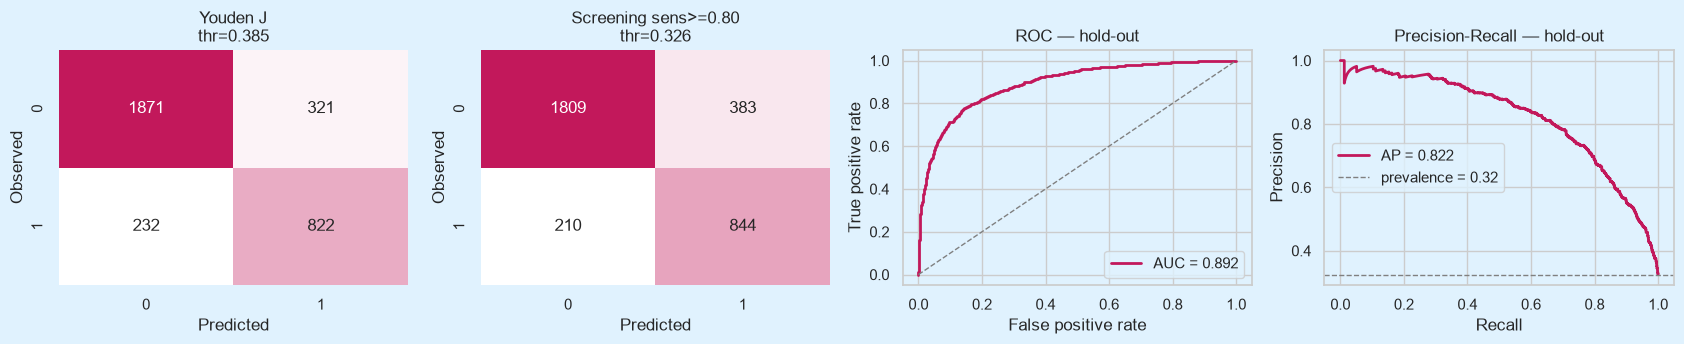

              precision    recall  f1-score   support

 No dementia       0.89      0.85      0.87      2192
    Dementia       0.72      0.78      0.75      1054

    accuracy                           0.83      3246
   macro avg       0.80      0.82      0.81      3246
weighted avg       0.83      0.83      0.83      3246



In [33]:
# --- LSTM hold-out figures: confusion matrices + ROC / PR curves -----------------------
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (name, thr) in zip(axes[:2], [("Youden J", lstm_thr_y),
                                      ("Screening sens>=0.80", lstm_thr_s)]):
    cm = confusion_matrix(y_test, (proba_lstm >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap=rasp_cmap, cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{name}\nthr={thr:.3f}")
fpr_l, tpr_l, _ = roc_curve(y_test, proba_lstm)
axes[2].plot(fpr_l, tpr_l, color=PRIMARY, lw=2, label=f"AUC = {lstm_auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC — hold-out"); axes[2].legend()
prec_l, rec_l, _ = precision_recall_curve(y_test, proba_lstm)
axes[3].plot(rec_l, prec_l, color=PRIMARY, lw=2, label=f"AP = {lstm_pr:.3f}")
axes[3].axhline(y_test.mean(), ls="--", c="grey", lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall — hold-out"); axes[3].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, lstm_yhat_y, target_names=["No dementia", "Dementia"]))

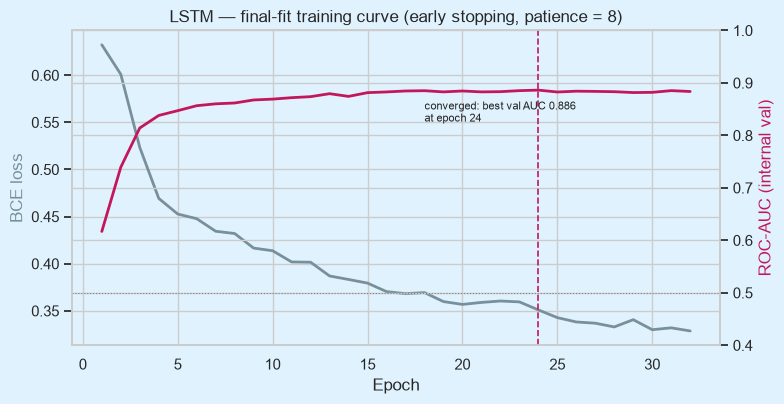

In [34]:
# --- LSTM training curves with convergence markers -------------------------------------
hist = lstm_final.history_
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(hist["epoch"], hist["train_loss"], color=NEUTRAL, lw=2, label="train loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss", color=NEUTRAL)
ax2 = ax1.twinx()
ax2.plot(hist["epoch"], hist["val_auc"], color=PRIMARY, lw=2, label="internal-val AUC")
ax2.set_ylabel("ROC-AUC (internal val)", color=PRIMARY)
ax2.axhline(0.5, ls=":", c="grey", lw=0.8)
ax2.axvline(hist["best_epoch"], ls="--", c=PRIMARY, lw=1.2)
ax2.annotate(f"converged: best val AUC {hist['best_val_auc']:.3f}\nat epoch {hist['best_epoch']}",
             xy=(hist["best_epoch"], hist["best_val_auc"]),
             xytext=(hist["best_epoch"] - 6, hist["best_val_auc"] - 0.06), fontsize=8)
ax2.set_ylim(0.4, 1.0)
plt.title("LSTM — final-fit training curve (early stopping, patience = 8)")
plt.tight_layout(); plt.show()

Fitting out-of-fold predictions for isotonic calibration (5 folds, quiet training)...


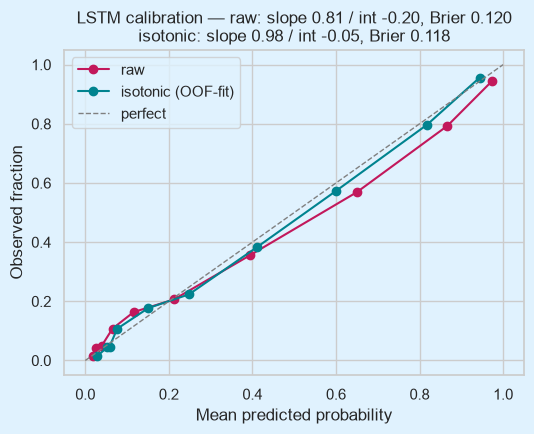

In [35]:
# --- LSTM calibration: raw vs out-of-fold isotonic -------------------------------------
# The isotonic mapping is fitted on TRAIN-only out-of-fold predictions, then applied to the
# hold-out; the hold-out never recalibrates itself.
print("Fitting out-of-fold predictions for isotonic calibration (5 folds, quiet training)...")
lstm_oof = calibration_oof(make_lstm, X_train, y_train)
lstm_iso = IsotonicRegression(out_of_bounds="clip").fit(lstm_oof, y_train)
proba_lstm_iso = lstm_iso.predict(proba_lstm)

lstm_slope_raw, lstm_int_raw = calib_slope_intercept(y_test, proba_lstm)
lstm_slope_iso, lstm_int_iso = calib_slope_intercept(y_test, proba_lstm_iso)
lstm_brier_iso = brier_score_loss(y_test, proba_lstm_iso)
lstm_logloss_iso = log_loss(y_test, np.clip(proba_lstm_iso, 1e-6, 1 - 1e-6))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for p, c, lbl in [(proba_lstm, PRIMARY, "raw"), (proba_lstm_iso, SECONDARY, "isotonic (OOF-fit)")]:
    frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
ax.set_title(f"LSTM calibration — raw: slope {lstm_slope_raw:.2f} / int {lstm_int_raw:.2f}, "
             f"Brier {lstm_brier:.3f}\nisotonic: slope {lstm_slope_iso:.2f} / int {lstm_int_iso:.2f}, "
             f"Brier {lstm_brier_iso:.3f}")
ax.legend()
plt.tight_layout(); plt.show()

In [36]:
# --- LSTM subgroup performance (sex, residence) ----------------------------------------
lstm_sub = subgroup_table(X_test, y_test.values, proba_lstm)
display(lstm_sub.round(3))
print("Drift check: compare mean_pred vs observed (calibration) per row.")

,subgroup,n,events,ROC-AUC,mean_pred,observed
0,Sex: Female,1862,663,0.887,0.372,0.356
1,Sex: Male,1384,391,0.895,0.288,0.283
2,Residence: Rural,2156,705,0.892,0.345,0.327
3,Residence: Urban,1090,349,0.892,0.318,0.320


Drift check: compare mean_pred vs observed (calibration) per row.


,feature,importance,sd
0,hypertension_dx,0.0815,0.0022
1,age_years,0.0626,0.0029
2,residence,0.0604,0.0023
3,province,0.0258,0.0025
4,diastolic_bp_mmhg,0.0223,0.0024
5,systolic_bp_mmhg,0.0208,0.0020
6,employment_status,0.0183,0.0016
7,takes_bp_medication,0.0091,0.0009
8,gds15_score,0.0081,0.0014
9,lives_alone,0.0078,0.0013


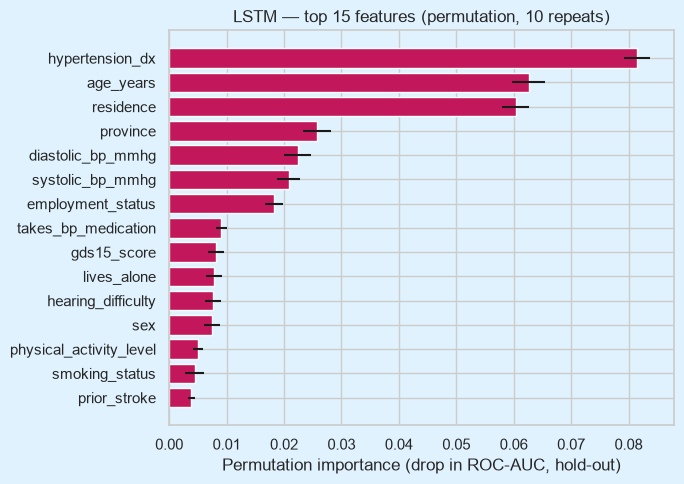

In [37]:
# --- LSTM permutation importance (hold-out, 10 repeats) --------------------------------
lstm_test_tensors = BUILDER.transform(X_test)
def _lstm_perm_predict(ts):
    pp = predict_pos(lstm_final.model_, ts)
    return np.column_stack([1 - pp, pp])

LSTM_SPEC = ([("cont", j, name) for j, name in enumerate(CONT_COLS)]
             + [("cat", j, name) for j, name in enumerate(CAT_COLS)])
lstm_perm_tab = permutation_importance_deep(_lstm_perm_predict, lstm_test_tensors, LSTM_SPEC,
                                            y_test.values, n_repeats=10, seed=RANDOM_STATE)
display(lstm_perm_tab.head(15).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
top = lstm_perm_tab.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["sd"], color=PRIMARY)
ax.set_xlabel("Permutation importance (drop in ROC-AUC, hold-out)")
ax.set_title("LSTM — top 15 features (permutation, 10 repeats)")
plt.tight_layout(); plt.show()

In [38]:
# --- LSTM export: benchmark artifacts for evaluations.ipynb ----------------------------
lstm_holdout_block = {
    "roc_auc": float(lstm_auc), "pr_auc": float(lstm_pr),
    "brier_raw": float(lstm_brier), "brier_isotonic": float(lstm_brier_iso),
    "logloss_raw": float(lstm_logloss), "logloss_isotonic": float(lstm_logloss_iso),
    "calib_slope_raw": lstm_slope_raw, "calib_intercept_raw": lstm_int_raw,
    "calib_slope_isotonic": lstm_slope_iso, "calib_intercept_isotonic": lstm_int_iso,
    "threshold_youden": float(lstm_thr_y), "threshold_screen": float(lstm_thr_s),
    "mcc_youden": float(lstm_mcc), "balanced_accuracy_youden": float(lstm_balacc),
    "youden": {k: float(v) for k, v in lstm_points["Youden J"].items()},
    "screening": {k: float(v) for k, v in lstm_points["Screening (sens>=0.80)"].items()},
}
lstm_metrics = {
    "model": "LSTM (tabular-as-sequence)", "slug": "lstm",
    "framework": f"torch {torch.__version__} ({DEVICE.type.upper()})",
    "device": str(DEVICE),
    "n_trainable_params": lstm_final.n_params_,
    "best_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in lstm_best.items()},
    "cv_default": lstm_default_sum, "cv_tuned": lstm_tuned_sum,
    "search_top5": lstm_search_tab.head(5).round(4).to_dict(orient="records"),
    "convergence": {k: lstm_final.history_[k] for k in
                    ["best_val_auc", "best_epoch", "stopped_epoch", "early_stopped", "fit_seconds"]},
    "history": lstm_final.history_,
    "holdout": lstm_holdout_block,
    "subgroups": lstm_sub.round(4).to_dict(orient="records"),
    "perm_importance_top15": lstm_perm_tab.head(15).round(5).to_dict(orient="records"),
}
with open(BENCH / "lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=2, default=str)
pd.DataFrame({"y_true": y_test.values, "proba_raw": proba_lstm,
              "proba_isotonic": proba_lstm_iso,
              "sex": X_test["sex"].values, "residence": X_test["residence"].values}
             ).to_csv(BENCH / "lstm_holdout_predictions.csv", index=False)
print(f"Artifacts written: {BENCH / 'lstm_metrics.json'}")
print(f"                   {BENCH / 'lstm_holdout_predictions.csv'}")

Artifacts written: outputs\benchmark\lstm_metrics.json
                   outputs\benchmark\lstm_holdout_predictions.csv


### 7.4 Deployable checkpoint

The final LSTM is serialised as a self-contained deployment bundle — network weights, the
fitted sequence builder, the isotonic calibrator and both operating-point thresholds — with an
MD5 checksum written alongside (`*.pt.md5`). The reload check below rebuilds the network from
the bundle and verifies it reproduces the hold-out probabilities.

In [39]:
# --- LSTM deployable checkpoint (weights + transformer + calibrator + thresholds) ------
CKPT_DIR = OUT_DIR / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

lstm_payload = {
    "model": "TabularLSTM (tabular-as-sequence)",
    "task": "dementia screening",
    "trained_on": "data1.csv",
    "torch_version": torch.__version__,
    "model_kwargs": {"cat_cards": BUILDER.cards_,
                     **{k: lstm_final.params[k]
                        for k in ("d_model", "hidden", "layers", "dropout")}},
    "model_state": lstm_final.model_.state_dict(),
    "transformer": BUILDER,                    # fitted SequenceBuilder (pickled with the bundle)
    "calibration": {"method": "isotonic",
                    "x_thresholds": lstm_iso.X_thresholds_,
                    "y_thresholds": lstm_iso.y_thresholds_},
    "operating_points": {"youden": lstm_thr_y, "screening": lstm_thr_s},
    "holdout_metrics": {"roc_auc": lstm_auc, "pr_auc": lstm_pr, "brier": lstm_brier},
}
lstm_md5 = save_checkpoint(CKPT_DIR / "lstm_dementia_screening.pt", lstm_payload)

# Integrity check: rebuild the network from the bundle and reproduce hold-out scores.
_ckpt = torch.load(CKPT_DIR / "lstm_dementia_screening.pt", weights_only=False)
_net = TabularLSTM(**_ckpt["model_kwargs"])
_net.load_state_dict(_ckpt["model_state"])
_net.eval()   # inference mode — dropout off
with torch.no_grad():
    _p = torch.sigmoid(_net(*_ckpt["transformer"].transform(X_test.iloc[:512]))).numpy()
assert np.allclose(_p, proba_lstm[:512], atol=1e-5)
print("reload check passed — the checkpoint reproduces hold-out probabilities")

checkpoint saved: outputs\checkpoints\lstm_dementia_screening.pt
md5 checksum:     0d20d8fcd827cf92fe4d4021b7c93ac5  -> outputs\checkpoints\lstm_dementia_screening.pt.md5
reload check passed — the checkpoint reproduces hold-out probabilities


## 8. Secondary Model — Deep Neural Network (GPU)

A plain deep feed-forward classifier (multi-layer perceptron) on the 47-column standardised +
one-hot design matrix built in section 5 — the standard "deep learning on tabular data"
formulation, and the natural dense counterpart to the sequence-based LSTM: it sees the same
rows as an unordered feature vector, while the LSTM reads them as a token sequence.

Expectation to test, stated up front: with the enriched (+) class (~32% of rows) there are now
thousands of events for a network with orders of magnitude more parameters than a linear model
— the interesting question is whether regularisation + early stopping turn that capacity into
better discrimination than the LSTM, or whether the MLP merely matches it. Same GPU training
path (CUDA + mixed precision, cuDNN autotuner), same early stopping, same tuning protocol.

In [40]:
# --- DNN: design matrix (from section 5), model, wrapper, search grid ------------------
def _dense(a):
    a = a.toarray() if _sparse.issparse(a) else np.asarray(a)
    return a.astype(np.float32)

X_tr_mat, X_te_mat = _dense(X_train_p), _dense(X_test_p)     # float32 torch-ready matrices
DNN_FEATURES = feature_names
print(f"Design matrix (section 5, train-fit transforms): "
      f"{X_tr_mat.shape[0]:,} x {X_tr_mat.shape[1]} float32 features")

class MLP(nn.Module):
    # Deep feed-forward network: Linear -> BatchNorm -> ReLU -> Dropout blocks.
    def __init__(self, n_features=X_tr_mat.shape[1], hidden=(128, 64), dropout=0.2):
        super().__init__()
        layers, prev = [], n_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

class TorchMatrixClassifier:
    # sklearn-flavoured wrapper: fit/predict_proba over the preprocessed matrix.
    def __init__(self, **params):
        self.params = dict(hidden=(128, 64), dropout=0.2, lr=1e-3, weight_decay=0.0,
                           batch_size=256, max_epochs=100, patience=8)
        self.params.update(params)
    def fit(self, Xa, yser, verbose=False):
        ya = np.asarray(yser)
        self.model_ = MLP(n_features=Xa.shape[1], hidden=tuple(self.params["hidden"]),
                          dropout=self.params["dropout"])
        tensors = [torch.as_tensor(np.asarray(Xa, dtype=np.float32))]
        train_kw = {k: self.params[k] for k in TRAIN_KEYS if k in self.params}
        self.model_, self.history_, self.best_val_auc_ = train_torch(
            self.model_, tensors, ya, verbose=verbose, **train_kw)
        self.n_params_ = sum(p.numel() for p in self.model_.parameters())
        return self
    def predict_proba(self, Xa):
        p = predict_pos(self.model_, [torch.as_tensor(np.asarray(Xa, dtype=np.float32))])
        return np.column_stack([1 - p, p])

def make_dnn(**over):
    return TorchMatrixClassifier(**over)

PARAM_GRID_DNN = {"hidden": [(128, 64), (256, 128), (128, 128, 64), (64, 32)],
                  "dropout": [0.0, 0.2, 0.4], "lr": [1e-3, 3e-4],
                  "weight_decay": [0.0, 1e-4], "batch_size": [256, 512]}

_probe_mlp = MLP(n_features=X_tr_mat.shape[1])
print(f"MLP capacity (default config): {sum(p.numel() for p in _probe_mlp.parameters()):,} "
      f"trainable parameters")

Design matrix (section 5, train-fit transforms): 12,983 x 47 float32 features
MLP capacity (default config): 14,849 trainable parameters


### 8.1 Cross-validated performance (default hyperparameters)

Same protocol as the LSTM: stratified 5-fold CV on the training partition with default
hyperparameters first.

In [41]:
# --- DNN default 5-fold CV -------------------------------------------------------------
print("DNN — default hyperparameters, 5-fold stratified CV:")
dnn_default_tab, dnn_default_sum = cv_evaluate(make_dnn, X_tr_mat, y_train)

DNN — default hyperparameters, 5-fold stratified CV:


,fold,ROC-AUC,PR-AUC,Brier
0,1,0.8877,0.8201,0.1197
1,2,0.8845,0.8177,0.1210
2,3,0.8744,0.8050,0.1250
3,4,0.8733,0.7919,0.1304
4,5,0.8658,0.7830,0.1332


   -> CV ROC-AUC 0.877 +/- 0.009 | PR-AUC 0.804 | Brier 0.1259


### 8.2 Hyperparameter tuning (randomised search)

Randomised search over width/depth, dropout, learning rate, weight decay and batch size —
3-fold CV ROC-AUC on the train partition only, one line per trial, then a fresh 5-fold CV
with the winning configuration.

In [42]:
# --- DNN randomised search (3-fold, ROC-AUC) + tuned 5-fold CV -------------------------
print("DNN — randomised hyperparameter search:")
dnn_search_tab, dnn_best = random_search(make_dnn, PARAM_GRID_DNN, X_tr_mat, y_train, n_iter=12)

display(dnn_search_tab.head(5).round(4))

print("\nDNN — winning configuration, fresh 5-fold CV:")
dnn_tuned_tab, dnn_tuned_sum = cv_evaluate(lambda: make_dnn(**dnn_best), X_tr_mat, y_train)

dnn_cmp = pd.DataFrame({
    "CV ROC-AUC": [dnn_default_sum["ROC-AUC"][0], dnn_tuned_sum["ROC-AUC"][0]],
    "CV PR-AUC":  [dnn_default_sum["PR-AUC"][0], dnn_tuned_sum["PR-AUC"][0]],
    "CV Brier":   [dnn_default_sum["Brier"][0], dnn_tuned_sum["Brier"][0]],
}, index=["DNN default", "DNN tuned"])
display(dnn_cmp.round(4))

DNN — randomised hyperparameter search:


   trial  1/12 | weight_decay=0.0, lr=0.001, hidden=(128, 64), dropout=0.4, batch_size=512 | 3-fold AUC 0.8752 +/- 0.0050 (11.9s)


   trial  2/12 | weight_decay=0.0001, lr=0.001, hidden=(64, 32), dropout=0.2, batch_size=512 | 3-fold AUC 0.8718 +/- 0.0057 (10.7s)


   trial  3/12 | weight_decay=0.0001, lr=0.001, hidden=(128, 128, 64), dropout=0.2, batch_size=512 | 3-fold AUC 0.8707 +/- 0.0038 (9.4s)


   trial  4/12 | weight_decay=0.0, lr=0.0003, hidden=(64, 32), dropout=0.4, batch_size=512 | 3-fold AUC 0.8657 +/- 0.0045 (27.5s)


...

,config,weight_decay,lr,hidden,dropout,batch_size,cv_auc,cv_sd,seconds
0,5,0.0001,0.0010,"(128, 64)",0.4,256,0.8772,0.0047,17.3
1,1,0.0000,0.0010,"(128, 64)",0.4,512,0.8752,0.0050,11.9
2,8,0.0000,0.0003,"(128, 128, 64)",0.4,256,0.8738,0.0035,40.4
3,11,0.0000,0.0010,"(128, 64)",0.2,512,0.8731,0.0051,10.4
4,12,0.0000,0.0003,"(64, 32)",0.2,256,0.8731,0.0060,29.9



DNN — winning configuration, fresh 5-fold CV:


,fold,ROC-AUC,PR-AUC,Brier
0,1,0.8879,0.8190,0.1191
1,2,0.8871,0.8240,0.1191
2,3,0.8763,0.8063,0.1239
3,4,0.8774,0.7981,0.1272
4,5,0.8686,0.7856,0.1304


   -> CV ROC-AUC 0.879 +/- 0.008 | PR-AUC 0.807 | Brier 0.1239


,CV ROC-AUC,CV PR-AUC,CV Brier
DNN default,0.8771,0.8035,0.1259
DNN tuned,0.8795,0.8066,0.1239


### 8.3 Final fit — per-epoch training log — hold-out evaluation

Final DNN fit on the full training partition with tuned hyperparameters (full per-epoch log +
convergence statement), then a single hold-out evaluation at the same two operating points.

In [43]:
# --- Final DNN fit (per-epoch log) + hold-out probabilities ----------------------------
print(f"Final DNN fit — params: {dnn_best}\n")
dnn_final = make_dnn(**dnn_best)
dnn_final.fit(X_tr_mat, y_train, verbose=True)

proba_dnn = dnn_final.predict_proba(X_te_mat)[:, 1]
dnn_auc = roc_auc_score(y_test, proba_dnn)
dnn_pr = average_precision_score(y_test, proba_dnn)
dnn_brier = brier_score_loss(y_test, proba_dnn)
dnn_logloss = log_loss(y_test, proba_dnn)
dnn_thr_y, dnn_thr_s, dnn_points = operating_points(y_test, proba_dnn)
dnn_yhat_y = (proba_dnn >= dnn_thr_y).astype(int)
dnn_mcc = matthews_corrcoef(y_test, dnn_yhat_y)
dnn_balacc = balanced_accuracy_score(y_test, dnn_yhat_y)
if DEVICE.type == "cuda":
    print(f"\nGPU peak memory during final fit: {torch.cuda.max_memory_allocated() / 1e6:.0f} MB")

pts = pd.DataFrame(dnn_points).T.round(3)
pts["threshold"] = [dnn_thr_y, dnn_thr_s]
display(pts)
print(f"\nHold-out ROC-AUC = {dnn_auc:.3f} | PR-AUC = {dnn_pr:.3f} | Brier = {dnn_brier:.3f} "
      f"| log-loss = {dnn_logloss:.3f}")
print(f"Youden point: MCC = {dnn_mcc:.3f} | balanced accuracy = {dnn_balacc:.3f}")

Final DNN fit — params: {'weight_decay': 0.0001, 'lr': 0.001, 'hidden': (128, 64), 'dropout': 0.4, 'batch_size': 256}



   epoch   1 | train loss 0.5928 | val AUC 0.8074 | best 0.8074  <- new best
   epoch   2 | train loss 0.4983 | val AUC 0.8295 | best 0.8295  <- new best


   epoch   3 | train loss 0.4777 | val AUC 0.8365 | best 0.8365  <- new best
   epoch   4 | train loss 0.4653 | val AUC 0.8404 | best 0.8404  <- new best


   epoch   5 | train loss 0.4613 | val AUC 0.8470 | best 0.8470  <- new best


   epoch   6 | train loss 0.4500 | val AUC 0.8517 | best 0.8517  <- new best
   epoch   7 | train loss 0.4432 | val AUC 0.8545 | best 0.8545  <- new best


...

   epoch  46 | train loss 0.3565 | val AUC 0.8801 | best 0.8836  (no improvement for 4 epoch(s))
   epoch  47 | train loss 0.3551 | val AUC 0.8813 | best 0.8836  (no improvement for 5 epoch(s))


   epoch  48 | train loss 0.3527 | val AUC 0.8820 | best 0.8836  (no improvement for 6 epoch(s))
   epoch  49 | train loss 0.3553 | val AUC 0.8805 | best 0.8836  (no improvement for 7 epoch(s))


   epoch  50 | train loss 0.3515 | val AUC 0.8810 | best 0.8836  (no improvement for 8 epoch(s))
   -> early stopping triggered: no val-AUC improvement for 8 consecutive epochs (stopped at epoch 50)
   -> CONVERGED at epoch 42: best internal-validation ROC-AUC = 0.8836 (best weights restored) | wall-clock 10.0s

GPU peak memory during final fit: 187 MB


,sensitivity,specificity,PPV,NPV,threshold
Youden J,0.789,0.819,0.678,0.890,0.318860
Screening (sens>=0.80),0.801,0.805,0.664,0.894,0.297995



Hold-out ROC-AUC = 0.884 | PR-AUC = 0.812 | Brier = 0.124 | log-loss = 0.390
Youden point: MCC = 0.588 | balanced accuracy = 0.804


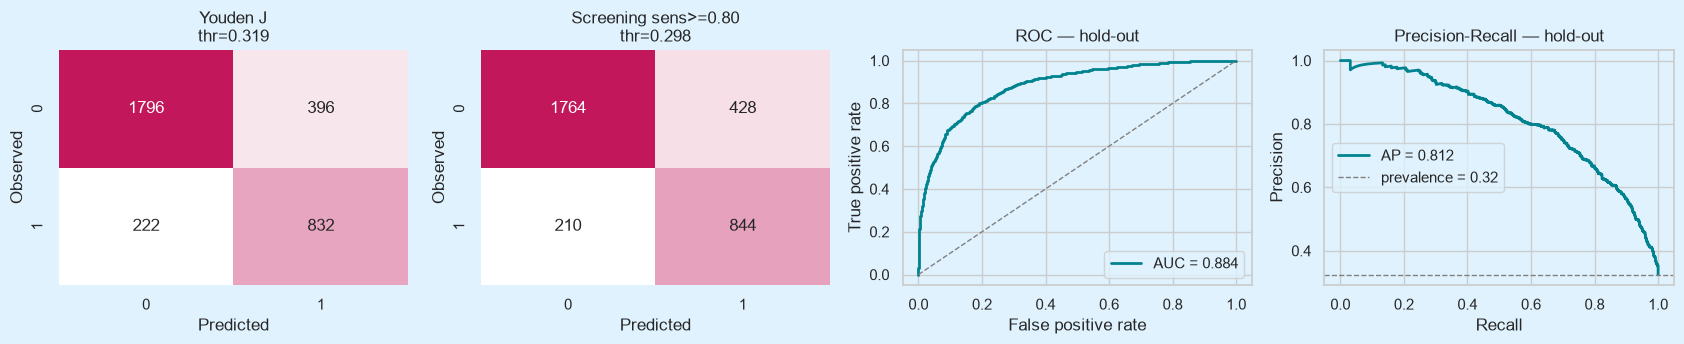

              precision    recall  f1-score   support

 No dementia       0.89      0.82      0.85      2192
    Dementia       0.68      0.79      0.73      1054

    accuracy                           0.81      3246
   macro avg       0.78      0.80      0.79      3246
weighted avg       0.82      0.81      0.81      3246



In [44]:
# --- DNN hold-out figures: confusion matrices + ROC / PR curves ------------------------
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (name, thr) in zip(axes[:2], [("Youden J", dnn_thr_y),
                                      ("Screening sens>=0.80", dnn_thr_s)]):
    cm = confusion_matrix(y_test, (proba_dnn >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap=rasp_cmap, cbar=False, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    ax.set_title(f"{name}\nthr={thr:.3f}")
fpr_d, tpr_d, _ = roc_curve(y_test, proba_dnn)
axes[2].plot(fpr_d, tpr_d, color=SECONDARY, lw=2, label=f"AUC = {dnn_auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", c="grey", lw=1)
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC — hold-out"); axes[2].legend()
prec_d, rec_d, _ = precision_recall_curve(y_test, proba_dnn)
axes[3].plot(rec_d, prec_d, color=SECONDARY, lw=2, label=f"AP = {dnn_pr:.3f}")
axes[3].axhline(y_test.mean(), ls="--", c="grey", lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[3].set_xlabel("Recall"); axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall — hold-out"); axes[3].legend()
plt.tight_layout(); plt.show()

print(classification_report(y_test, dnn_yhat_y, target_names=["No dementia", "Dementia"]))

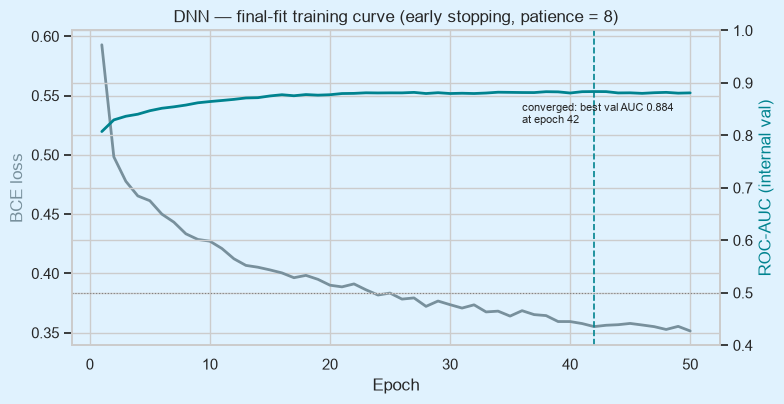

In [45]:
# --- DNN training curves with convergence markers --------------------------------------
hist = dnn_final.history_
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(hist["epoch"], hist["train_loss"], color=NEUTRAL, lw=2, label="train loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE loss", color=NEUTRAL)
ax2 = ax1.twinx()
ax2.plot(hist["epoch"], hist["val_auc"], color=SECONDARY, lw=2, label="internal-val AUC")
ax2.set_ylabel("ROC-AUC (internal val)", color=SECONDARY)
ax2.axhline(0.5, ls=":", c="grey", lw=0.8)
ax2.axvline(hist["best_epoch"], ls="--", c=SECONDARY, lw=1.2)
ax2.annotate(f"converged: best val AUC {hist['best_val_auc']:.3f}\nat epoch {hist['best_epoch']}",
             xy=(hist["best_epoch"], hist["best_val_auc"]),
             xytext=(hist["best_epoch"] - 6, hist["best_val_auc"] - 0.06), fontsize=8)
ax2.set_ylim(0.4, 1.0)
plt.title("DNN — final-fit training curve (early stopping, patience = 8)")
plt.tight_layout(); plt.show()

Fitting out-of-fold predictions for isotonic calibration (5 folds, quiet training)...


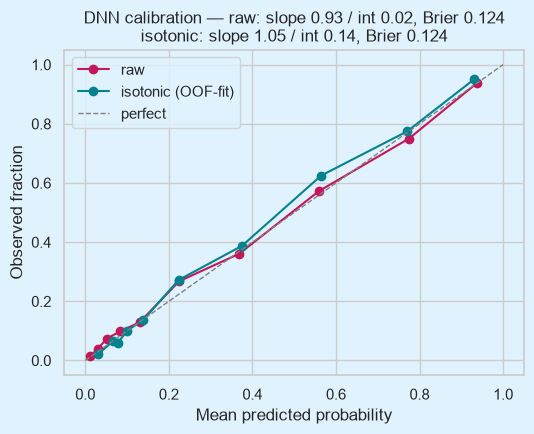

In [46]:
# --- DNN calibration: raw vs out-of-fold isotonic --------------------------------------
print("Fitting out-of-fold predictions for isotonic calibration (5 folds, quiet training)...")
dnn_oof = calibration_oof(make_dnn, X_tr_mat, y_train)
dnn_iso = IsotonicRegression(out_of_bounds="clip").fit(dnn_oof, y_train)
proba_dnn_iso = dnn_iso.predict(proba_dnn)

dnn_slope_raw, dnn_int_raw = calib_slope_intercept(y_test, proba_dnn)
dnn_slope_iso, dnn_int_iso = calib_slope_intercept(y_test, proba_dnn_iso)
dnn_brier_iso = brier_score_loss(y_test, proba_dnn_iso)
dnn_logloss_iso = log_loss(y_test, np.clip(proba_dnn_iso, 1e-6, 1 - 1e-6))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for p, c, lbl in [(proba_dnn, PRIMARY, "raw"), (proba_dnn_iso, SECONDARY, "isotonic (OOF-fit)")]:
    frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, "o-", color=c, label=lbl)
ax.plot([0, 1], [0, 1], "--", c="grey", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraction")
ax.set_title(f"DNN calibration — raw: slope {dnn_slope_raw:.2f} / int {dnn_int_raw:.2f}, "
             f"Brier {dnn_brier:.3f}\nisotonic: slope {dnn_slope_iso:.2f} / int {dnn_int_iso:.2f}, "
             f"Brier {dnn_brier_iso:.3f}")
ax.legend()
plt.tight_layout(); plt.show()

In [47]:
# --- DNN subgroup performance (sex, residence) -----------------------------------------
dnn_sub = subgroup_table(X_test, y_test.values, proba_dnn)
display(dnn_sub.round(3))
print("Drift check: compare mean_pred vs observed (calibration) per row.")

,subgroup,n,events,ROC-AUC,mean_pred,observed
0,Sex: Female,1862,663,0.876,0.348,0.356
1,Sex: Male,1384,391,0.892,0.276,0.283
2,Residence: Rural,2156,705,0.885,0.321,0.327
3,Residence: Urban,1090,349,0.882,0.310,0.320


Drift check: compare mean_pred vs observed (calibration) per row.


,feature,importance,sd
0,hypertension_dx,0.0822,0.0043
1,age_years,0.0726,0.0039
2,residence_Urban,0.0441,0.0037
3,systolic_bp_mmhg,0.0239,0.0021
4,diastolic_bp_mmhg,0.0197,0.0019
5,gds15_score,0.0142,0.0017
6,employment_status_Subsistence Farming,0.0121,0.0016
7,lives_alone,0.0097,0.0011
8,hearing_difficulty,0.0089,0.0015
9,sex_Male,0.0086,0.0014


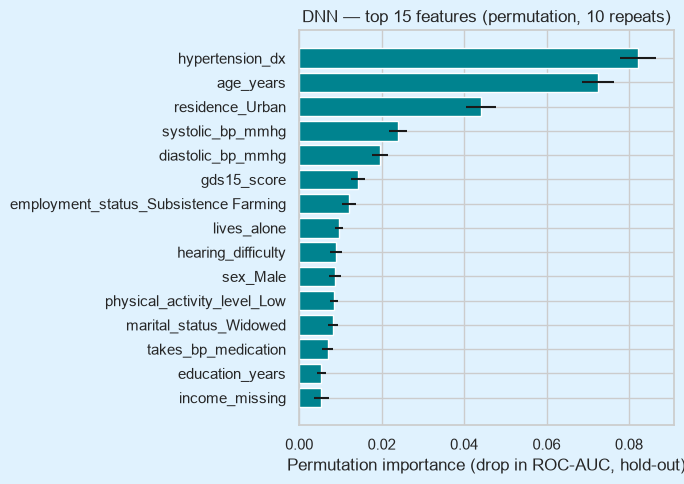

In [48]:
# --- DNN permutation importance (hold-out, 10 repeats) ---------------------------------
def _dnn_perm_predict(ts):
    pp = predict_pos(dnn_final.model_, ts)
    return np.column_stack([1 - pp, pp])

DNN_SPEC = [("plain", j, name) for j, name in enumerate(DNN_FEATURES)]
dnn_perm_tab = permutation_importance_deep(
    _dnn_perm_predict, [torch.as_tensor(X_te_mat)], DNN_SPEC,
    y_test.values, n_repeats=10, seed=RANDOM_STATE)
display(dnn_perm_tab.head(15).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
top = dnn_perm_tab.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["sd"], color=SECONDARY)
ax.set_xlabel("Permutation importance (drop in ROC-AUC, hold-out)")
ax.set_title("DNN — top 15 features (permutation, 10 repeats)")
plt.tight_layout(); plt.show()

In [49]:
# --- DNN export: benchmark artifacts for evaluations.ipynb -----------------------------
dnn_holdout_block = {
    "roc_auc": float(dnn_auc), "pr_auc": float(dnn_pr),
    "brier_raw": float(dnn_brier), "brier_isotonic": float(dnn_brier_iso),
    "logloss_raw": float(dnn_logloss), "logloss_isotonic": float(dnn_logloss_iso),
    "calib_slope_raw": dnn_slope_raw, "calib_intercept_raw": dnn_int_raw,
    "calib_slope_isotonic": dnn_slope_iso, "calib_intercept_isotonic": dnn_int_iso,
    "threshold_youden": float(dnn_thr_y), "threshold_screen": float(dnn_thr_s),
    "mcc_youden": float(dnn_mcc), "balanced_accuracy_youden": float(dnn_balacc),
    "youden": {k: float(v) for k, v in dnn_points["Youden J"].items()},
    "screening": {k: float(v) for k, v in dnn_points["Screening (sens>=0.80)"].items()},
}
dnn_metrics = {
    "model": "Deep Neural Network (MLP)", "slug": "dnn",
    "framework": f"torch {torch.__version__} ({DEVICE.type.upper()})",
    "device": str(DEVICE),
    "n_trainable_params": dnn_final.n_params_,
    "best_params": {k: (list(v) if isinstance(v, tuple) else v) for k, v in dnn_best.items()},
    "cv_default": dnn_default_sum, "cv_tuned": dnn_tuned_sum,
    "search_top5": dnn_search_tab.head(5).round(4).to_dict(orient="records"),
    "convergence": {k: dnn_final.history_[k] for k in
                    ["best_val_auc", "best_epoch", "stopped_epoch", "early_stopped", "fit_seconds"]},
    "history": dnn_final.history_,
    "holdout": dnn_holdout_block,
    "subgroups": dnn_sub.round(4).to_dict(orient="records"),
    "perm_importance_top15": dnn_perm_tab.head(15).round(5).to_dict(orient="records"),
}
with open(BENCH / "dnn_metrics.json", "w") as f:
    json.dump(dnn_metrics, f, indent=2, default=str)
pd.DataFrame({"y_true": y_test.values, "proba_raw": proba_dnn,
              "proba_isotonic": proba_dnn_iso,
              "sex": X_test["sex"].values, "residence": X_test["residence"].values}
             ).to_csv(BENCH / "dnn_holdout_predictions.csv", index=False)
print(f"Artifacts written: {BENCH / 'dnn_metrics.json'}")
print(f"                   {BENCH / 'dnn_holdout_predictions.csv'}")

Artifacts written: outputs\benchmark\dnn_metrics.json
                   outputs\benchmark\dnn_holdout_predictions.csv


### 8.4 Deployable checkpoint

The final DNN is serialised the same way — network weights, the fitted sklearn `ColumnTransformer`
(the full impute → scale → one-hot pipeline), the isotonic calibrator and both operating-point
thresholds — with an MD5 checksum (`*.pt.md5`) and a reload verification.

In [50]:
# --- DNN deployable checkpoint (weights + preprocessor + calibrator + thresholds) ------
CKPT_DIR = OUT_DIR / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

dnn_payload = {
    "model": "MLP (deep feed-forward network)",
    "task": "dementia screening",
    "trained_on": "data1.csv",
    "torch_version": torch.__version__,
    "model_kwargs": {"n_features": X_te_mat.shape[1],
                     "hidden": tuple(dnn_final.params["hidden"]),
                     "dropout": dnn_final.params["dropout"]},
    "model_state": dnn_final.model_.state_dict(),
    "transformer": preprocessor,               # fitted sklearn ColumnTransformer (pickled)
    "design_matrix_features": DNN_FEATURES,
    "calibration": {"method": "isotonic",
                    "x_thresholds": dnn_iso.X_thresholds_,
                    "y_thresholds": dnn_iso.y_thresholds_},
    "operating_points": {"youden": dnn_thr_y, "screening": dnn_thr_s},
    "holdout_metrics": {"roc_auc": dnn_auc, "pr_auc": dnn_pr, "brier": dnn_brier},
}
dnn_md5 = save_checkpoint(CKPT_DIR / "dnn_dementia_screening.pt", dnn_payload)

# Integrity check: rebuild the network from the bundle and reproduce hold-out scores.
_ckpt = torch.load(CKPT_DIR / "dnn_dementia_screening.pt", weights_only=False)
_net = MLP(**_ckpt["model_kwargs"])
_net.load_state_dict(_ckpt["model_state"])
_net.eval()   # inference mode — dropout off
_Xt = _ckpt["transformer"].transform(X_test.iloc[:512])
_Xt = _Xt.toarray() if _sparse.issparse(_Xt) else np.asarray(_Xt)
with torch.no_grad():
    _p = torch.sigmoid(_net(torch.as_tensor(_Xt, dtype=torch.float32))).numpy()
assert np.allclose(_p, proba_dnn[:512], atol=1e-5)
print("reload check passed — the checkpoint reproduces hold-out probabilities")

checkpoint saved: outputs\checkpoints\dnn_dementia_screening.pt
md5 checksum:     60f7a07f93ef698edc0ff588497d31de  -> outputs\checkpoints\dnn_dementia_screening.pt.md5
reload check passed — the checkpoint reproduces hold-out probabilities


## 9. Summary & Deployment

**What this notebook delivered**

1. **Data** — `data1.csv`: the class-enriched analysis cohort (>= 31.9% positives, ~33% after
   cleaning, vs ~8% in the source extract `data.csv`, which is retained unmodified), with
   realistic survey imperfections preserved: missing values, sentinel codes, date-format
   variants, label chaos, contradictions, duplicates.
2. **Cleaning** — deduplication on `participant_id`, sentinel conversion, impossible values
   repaired (`NaN`/swap) or row-rejected with a logged reason, categories harmonised, dates
   parsed, contradictions set to missing, eligibility (age >= 60) applied.
3. **EDA** — prevalence, missingness (before/after), distributions, crude associations,
   correlation structure incl. the leakage diagnostic for `cognitive_screen_score`
   (quarantined from the predictor pool).
4. **Primary model — LSTM (tabular-as-sequence)** — default + tuned 5-fold CV, randomised
   hyperparameter search, per-epoch training log with an explicit convergence statement,
   hold-out ROC/PR at Youden and screening operating points, isotonic recalibration, subgroup
   AUCs, permutation importance.
5. **Secondary model — DNN (GPU)** — the same protocol on the standardised + one-hot design
   matrix, with mixed-precision CUDA training.

**Deployment checkpoints** — `outputs/checkpoints/lstm_dementia_screening.pt` and
`outputs/checkpoints/dnn_dementia_screening.pt`, each shipped with an MD5 checksum
(`*.pt.md5`). Every bundle is self-contained: trained weights, the fitted input transformer,
the isotonic calibrator and both operating-point thresholds — everything needed to score new
records end-to-end. Verify integrity before loading:

```
md5sum -c outputs/checkpoints/*.pt.md5
```

**Next:** the dedicated `evaluations.ipynb` compares the two models in depth — discrimination
(paired DeLong test + bootstrap CIs), threshold behaviour and confusion structure (McNemar),
calibration, reclassification (NRI/IDI), decision curves, subgroup stability, training /
convergence behaviour and capacity — and closes with deployment recommendations.